<a href="https://colab.research.google.com/github/DanielRegaladoUMiami/logitech-forecast-project/blob/main/Individual_Project_DanielRegalado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual Project — Time Series Analysis & Forecasting
## Logitech Sales Data: Cleaning, EDA & Multi-Model Forecasting

**Course:** MAS 640 — Time Series Analysis and Forecasting  
**Student:** Daniel Regalado Cardoso  

---

### Project Overview

This notebook analyzes a messy monthly sales dataset spanning multiple product categories and regions. The workflow follows a structured pipeline:

| Stage | Description |
|-------|-------------|
| **Part 1** | Data loading & cleaning — handle empty rows, negatives, duplicates, discontinued products |
| **Part 2** | Exploratory Data Analysis — seasonality, trends, growth rates, correlations |
| **Part 3** | Time series diagnostics — stationarity tests, decomposition, ACF/PACF |
| **Part 4** | Forecasting — SARIMAX, Log-SARIMAX, ETS, 7 Nixtla models, ML (GB + RF), baselines, and ensemble |
| **Part 5** | Critique & next steps |

**Models used:** SARIMAX (AIC-based), Log-SARIMAX, ETS (Holt-Winters), Nixtla StatsForecast (AutoARIMA, AutoETS, AutoTheta, AutoCES, DynOptTheta, OptTheta, MSTL), Gradient Boosting, Random Forest, Seasonal Naive, Drift, and Ensemble averaging.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product as iterproduct
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Nixtla StatsForecast — full model suite
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA, AutoETS as NixtlaAutoETS, AutoTheta,
    AutoCES, DynamicOptimizedTheta, OptimizedTheta, MSTL,
    SeasonalNaive as NixtlaSN
)

# Plotting style
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.dpi': 100,
})

DATA_PATH = 'https://raw.githubusercontent.com/DanielRegaladoUMiami/logitech-forecast-project/main/data/interview_use_case.csv'

Setup complete — statsmodels + sklearn + Nixtla StatsForecast (7 models) loaded.


---
# Part 1: Data Loading & Cleaning

The raw dataset is intentionally messy — a real-world scenario common in interview cases. Issues to address:

| Issue | Description | Solution |
|-------|-------------|----------|
| Empty rows | Separator rows between data entries | Remove rows where all values are NaN |
| Wide format | One column per month | Melt to long format (date, sales) |
| Date parsing | Format `YY-Mon` (e.g., `10-Dec`) | Parse to `datetime` |
| Leading zeros | Products not yet launched | Trim pre-launch zeros |
| Trailing zeros | Discontinued products | Detect and trim |
| Negative values | Data entry errors | Replace with 0 |
| Duplicate categories | Same Cat1+Cat2+Cat3 for different sub-products | Keep as individual series with unique labels |
| NULL in Category3 | Missing subcategory | Keep labeled as `NULL` |

## 1.1 Load Raw Data & Initial Inspection

In [ ]:
raw = pd.read_csv(DATA_PATH, header=0)
print(f'Raw shape: {raw.shape}')
print(f'Columns: {list(raw.columns[:5])} ... {list(raw.columns[-5:])}')
print(f'\nFirst 5 rows (showing first 8 columns):')
raw.iloc[:8, :8]

Raw shape: (282, 72)
Columns: ['Category1', 'Category2', 'Category3', '10-Dec', '11-Jan'] ... ['16-Apr', '16-May', '16-Jun', '16-Jul', '16-Aug']

First 5 rows (showing first 8 columns):


,Category1,Category2,Category3,10-Dec,11-Jan,11-Feb,11-Mar,11-Apr
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A,X,W,0.0,0.0,0.0,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,A,A,A,0.0,0.0,0.0,0.0,0.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Step 1: Remove completely empty rows
# These are the separator rows between data entries
empty_mask = raw.isna().all(axis=1) | (raw.astype(str).apply(lambda x: x.str.strip()).eq('').all(axis=1))
print(f'Empty rows found: {empty_mask.sum()} out of {len(raw)}')

df_clean = raw[~empty_mask].copy().reset_index(drop=True)
print(f'After removing empty rows: {df_clean.shape}')
print(f'\nData rows (actual product series): {len(df_clean)}')

Empty rows found: 188 out of 282
After removing empty rows: (94, 72)

Data rows (actual product series): 94


In [ ]:
# Step 2: Rename category columns for clarity
date_cols = [c for c in df_clean.columns if c not in ['Category1', 'Category2', 'Category3']]
print(f'Category columns: Category1, Category2, Category3')
print(f'Date columns: {len(date_cols)} months')
print(f'Date range: {date_cols[0]} to {date_cols[-1]}')

Category columns: Category1, Category2, Category3
Date columns: 69 months
Date range: 10-Dec to 16-Aug


In [ ]:
# Step 3: Parse dates - convert column names like '10-Dec', '11-Jan' to proper dates
from datetime import datetime

def parse_date_col(col_name):
    """Convert format 'YY-Mon' to datetime. E.g. '10-Dec' -> 2010-12-01"""
    try:
        return pd.to_datetime(col_name, format='%y-%b')
    except:
        return None

date_map = {col: parse_date_col(col) for col in date_cols}
valid_dates = {k: v for k, v in date_map.items() if v is not None}
print(f'Successfully parsed {len(valid_dates)} / {len(date_cols)} date columns')
print(f'Date range: {min(valid_dates.values()).strftime("%Y-%m")} to {max(valid_dates.values()).strftime("%Y-%m")}')

Successfully parsed 69 / 69 date columns
Date range: 2010-12 to 2016-08


## 1.2 Reshape from Wide to Long Format

In [ ]:
# Create a unique series ID for each row
df_clean['series_id'] = range(len(df_clean))

# Melt: wide -> long
id_vars = ['series_id', 'Category1', 'Category2', 'Category3']
df_long = df_clean.melt(id_vars=id_vars, value_vars=list(valid_dates.keys()),
                         var_name='date_str', value_name='sales')

# Map date strings to actual dates
df_long['date'] = df_long['date_str'].map(valid_dates)
df_long['sales'] = pd.to_numeric(df_long['sales'], errors='coerce').fillna(0).astype(int)

# Create composite category key
df_long['cat_key'] = (df_long['Category1'].astype(str) + '_' +
                       df_long['Category2'].astype(str) + '_' +
                       df_long['Category3'].astype(str))

df_long = df_long.sort_values(['series_id', 'date']).reset_index(drop=True)

print(f'Long format shape: {df_long.shape}')
print(f'Unique series: {df_long["series_id"].nunique()}')
print(f'\nSample:')
df_long.head(10)

Long format shape: (6486, 8)
Unique series: 94

Sample:


,series_id,Category1,Category2,Category3,date_str,sales,date,cat_key
0,0,A,X,W,10-Dec,0,2010-12-01,A_X_W
1,0,A,X,W,11-Jan,0,2011-01-01,A_X_W
2,0,A,X,W,11-Feb,0,2011-02-01,A_X_W
3,0,A,X,W,11-Mar,0,2011-03-01,A_X_W
4,0,A,X,W,11-Apr,0,2011-04-01,A_X_W
5,0,A,X,W,11-May,0,2011-05-01,A_X_W
6,0,A,X,W,11-Jun,0,2011-06-01,A_X_W
7,0,A,X,W,11-Jul,0,2011-07-01,A_X_W
8,0,A,X,W,11-Aug,0,2011-08-01,A_X_W
9,0,A,X,W,11-Sep,0,2011-09-01,A_X_W


## 1.3 Data Quality Assessment

In [ ]:
print('='*70)
print('DATA QUALITY REPORT')
print('='*70)

# Fill NaN in Category3 with 'NULL'
df_long['Category3'] = df_long['Category3'].fillna('NULL').astype(str)
# Rebuild cat_key after fixing
df_long['cat_key'] = (df_long['Category1'].astype(str) + '_' +
                       df_long['Category2'].astype(str) + '_' +
                       df_long['Category3'].astype(str))

# Category overview
print(f'\n--- Category Structure ---')
print(f'Category1 values: {sorted(df_long["Category1"].dropna().unique())}')
print(f'Category2 values: {sorted(df_long["Category2"].dropna().unique())}')
print(f'Category3 values: {sorted(df_long["Category3"].dropna().unique())}')

# NULL categories
null_series = df_long[df_long['Category3'] == 'NULL']['series_id'].unique()
print(f'\n--- NULL Category3 ---')
print(f'Series with Category3=NULL: {len(null_series)}')

# Negative values
neg_mask = df_long['sales'] < 0
print(f'\n--- Negative Values ---')
print(f'Rows with negative sales: {neg_mask.sum()}')
if neg_mask.sum() > 0:
    print(df_long[neg_mask][['series_id', 'cat_key', 'date', 'sales']])

# Zeros analysis
print(f'\n--- Zero Values ---')
print(f'Total zero values: {(df_long["sales"]==0).sum()} ({(df_long["sales"]==0).mean()*100:.1f}%)')

DATA QUALITY REPORT

--- Category Structure ---
Category1 values: ['A', 'B', 'C']
Category2 values: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'X']
Category3 values: ['A', 'A1', 'A2', 'A3', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'NULL', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

--- NULL Category3 ---
Series with Category3=NULL: 13

--- Negative Values ---
Rows with negative sales: 1
      series_id   cat_key       date  sales
1141         16  A_C_NULL 2014-01-01  -2503

--- Zero Values ---
Total zero values: 2416 (37.2%)


In [ ]:
# Analyze each series for data patterns
series_stats = []
for sid in df_long['series_id'].unique():
    s = df_long[df_long['series_id']==sid].sort_values('date')
    vals = s['sales'].values
    cat1, cat2, cat3 = s['Category1'].iloc[0], s['Category2'].iloc[0], s['Category3'].iloc[0]

    # Count leading zeros
    leading_zeros = 0
    for v in vals:
        if v == 0:
            leading_zeros += 1
        else:
            break

    # Count trailing zeros
    trailing_zeros = 0
    for v in reversed(vals):
        if v == 0:
            trailing_zeros += 1
        else:
            break

    # Active period
    active_mask = vals != 0
    active_count = active_mask.sum()
    total_sales = vals.sum()
    has_negatives = (vals < 0).any()

    series_stats.append({
        'series_id': sid,
        'Category1': cat1, 'Category2': cat2, 'Category3': cat3,
        'cat_key': f'{cat1}_{cat2}_{cat3}',
        'total_months': len(vals),
        'leading_zeros': leading_zeros,
        'trailing_zeros': trailing_zeros,
        'active_months': active_count,
        'total_sales': total_sales,
        'mean_sales': vals[vals!=0].mean() if active_count > 0 else 0,
        'has_negatives': has_negatives,
    })

stats_df = pd.DataFrame(series_stats)
print('Series Summary:')
print(f'Total series: {len(stats_df)}')
print(f'\nLeading zeros pattern (products not yet launched):')
print(stats_df['leading_zeros'].value_counts().sort_index())
print(f'\nTrailing zeros pattern (discontinued products):')
print(stats_df[stats_df['trailing_zeros']>5][['cat_key', 'trailing_zeros', 'active_months']])

Series Summary:
Total series: 94

Leading zeros pattern (products not yet launched):
leading_zeros
0      2
25    90
26     1
45     1
Name: count, dtype: int64

Trailing zeros pattern (discontinued products):
   cat_key  trailing_zeros  active_months
48   B_A_N              29             40
59   B_F_S              29             40


In [ ]:
# Identify duplicate category combinations
dup_cats = stats_df.groupby('cat_key').size().reset_index(name='count')
dup_cats = dup_cats[dup_cats['count'] > 1]
print('Duplicate category combinations (same Cat1+Cat2+Cat3 appearing multiple times):')
print(dup_cats)
print(f'\nTotal duplicated category keys: {len(dup_cats)}')

# Show details for duplicates
for cat_key in dup_cats['cat_key'].values:
    subset = stats_df[stats_df['cat_key']==cat_key]
    print(f'\n  {cat_key}:')
    for _, row in subset.iterrows():
        print(f'    Series {row["series_id"]}: active_months={row["active_months"]}, '
              f'mean_sales={row["mean_sales"]:,.0f}, total_sales={row["total_sales"]:,.0f}')

Duplicate category combinations (same Cat1+Cat2+Cat3 appearing multiple times):
     cat_key  count
11  A_C_NULL      4
12     A_C_W      2
27  A_J_NULL      5
28     A_J_O      5
42     B_C_W      3
65     C_C_W      3

Total duplicated category keys: 6

  A_C_NULL:
    Series 14: active_months=44, mean_sales=4,649,127, total_sales=204,561,587
    Series 15: active_months=44, mean_sales=3,066,851, total_sales=134,941,441
    Series 16: active_months=44, mean_sales=7,741, total_sales=340,618
    Series 17: active_months=44, mean_sales=327,218, total_sales=14,397,589

  A_C_W:
    Series 12: active_months=44, mean_sales=787,776, total_sales=34,662,122
    Series 13: active_months=44, mean_sales=858,012, total_sales=37,752,507

  A_J_NULL:
    Series 36: active_months=44, mean_sales=330,046, total_sales=14,522,027
    Series 38: active_months=44, mean_sales=1,088,734, total_sales=47,904,287
    Series 39: active_months=44, mean_sales=1,188,563, total_sales=52,296,760
    Series 40: activ

## 1.4 Data Cleaning Decisions & Execution

Based on the quality assessment above, we apply 5 cleaning steps:

| Step | Action | Rationale |
|------|--------|----------|
| 1 | Replace negative values with 0 | Data entry errors — no valid business scenario for negative unit sales |
| 2 | Flag discontinued products | Series with 30+ trailing zeros indicate products pulled from catalog |
| 3 | Trim leading/trailing zeros | Remove pre-launch and post-discontinuation periods to avoid training on inactive data |
| 4 | Keep individual series (no aggregation) | See rationale below |
| 5 | Remove tiny series | Avg monthly sales < 1,000 are noise (likely test SKUs or data artifacts) |

### Why keep "duplicate" category keys as separate series?

Several category combinations (e.g., `B_C_W`) appear multiple times in the raw data. At first glance these look like duplicates, but inspecting their magnitudes reveals they are **distinct sub-products** sharing the same category hierarchy:

- `B_C_W` has series totaling **350M**, **310M**, and just **632** — clearly different products (possibly different SKUs, sizes, or distribution channels)

**Aggregating them would be incorrect** for two reasons:

1. **Signal contamination**: A series of 632 units/month has completely different dynamics (volatility, seasonality amplitude, trend) than one at 350M. Summing them buries the small series as rounding noise of the large one, and distorts the seasonality pattern of the large one.
2. **Forecast utility**: Business decisions happen at the sub-product level. A forecast of the aggregate tells you nothing about whether to stock more of the 350M product or discontinue the 632 one.

The correct alternative would be **hierarchical reconciliation** (forecasting each sub-product independently, then reconciling with the aggregate via top-down, bottom-up, or MinT optimal methods). This is noted as a potential next step in Part 5, but for this project scope, independent forecasting per series is the most defensible approach.

In [ ]:
# CLEANING STEP 1: Replace negatives with 0
neg_count = (df_long['sales'] < 0).sum()
df_long.loc[df_long['sales'] < 0, 'sales'] = 0
print(f'Step 1: Replaced {neg_count} negative values with 0')

# CLEANING STEP 2: Identify discontinued products (have data early, then all zeros at end)
discontinued = stats_df[stats_df['trailing_zeros'] >= 29]['series_id'].tolist()
print(f'\nStep 2: Identified {len(discontinued)} discontinued product series:')
for sid in discontinued:
    row = stats_df[stats_df['series_id']==sid].iloc[0]
    print(f'  Series {sid} ({row["cat_key"]}): {row["trailing_zeros"]} trailing zeros')

# CLEANING STEP 3: Trim leading/trailing zeros per series
df_active = []
for sid in df_long['series_id'].unique():
    s = df_long[df_long['series_id']==sid].sort_values('date').copy()
    vals = s['sales'].values

    # Find first non-zero
    first_nz = None
    for i, v in enumerate(vals):
        if v != 0:
            first_nz = i
            break

    if first_nz is not None:
        s = s.iloc[first_nz:]

    # For discontinued products, trim trailing zeros
    if sid in discontinued:
        vals_trimmed = s['sales'].values
        last_nz = len(vals_trimmed) - 1
        while last_nz >= 0 and vals_trimmed[last_nz] == 0:
            last_nz -= 1
        if last_nz >= 0:
            s = s.iloc[:last_nz+1]

    df_active.append(s)

df_long = pd.concat(df_active, ignore_index=True)
print(f'\nStep 3: Trimmed leading/trailing zeros')
print(f'Shape after trimming: {df_long.shape}')

Step 1: Replaced 1 negative values with 0

Step 2: Identified 2 discontinued product series:
  Series 48 (B_A_N): 29 trailing zeros
  Series 59 (B_F_S): 29 trailing zeros

Step 3: Trimmed leading/trailing zeros
Shape after trimming: (4107, 8)


In [ ]:
# CLEANING STEP 4: Keep individual series (NO aggregation of "duplicates")
# "Duplicate" cat_keys actually represent different sub-products with very different magnitudes
# E.g., B_C_W has series totaling 350M, 310M, and just 632 — clearly different products.

# Create a unique label for each series: cat_key + series_id suffix for duplicates
series_counts = df_long.groupby('cat_key')['series_id'].nunique()
dup_keys = series_counts[series_counts > 1].index.tolist()

# For duplicate cat_keys, append a suffix to disambiguate
def make_series_label(row):
    ck = row['cat_key']
    if ck in dup_keys:
        # Rank by total sales within group
        return f"{ck}_s{row['series_id']}"
    return ck

df_long['series_label'] = df_long.apply(make_series_label, axis=1)

print(f'Step 4: Kept individual series (no aggregation)')
print(f'  Duplicate cat_keys (multiple sub-products): {len(dup_keys)}')
for dk in dup_keys:
    n = df_long[df_long['cat_key']==dk]['series_id'].nunique()
    print(f'    {dk}: {n} sub-products')

# CLEANING STEP 5: Remove very small series (noise)
series_avg = df_long.groupby('series_label')['sales'].mean()
small_series = series_avg[series_avg < 1000].index.tolist()
print(f'\nStep 5: Identified {len(small_series)} very small series (avg monthly sales < 1,000)')
for sl in small_series:
    print(f'  {sl}: avg = {series_avg[sl]:,.0f}')

df_final = df_long[~df_long['series_label'].isin(small_series)].copy()

# Use series_label as the main identifier going forward
print(f'\nFinal cleaned dataset: {df_final["series_label"].nunique()} product series')
print(f'Total rows: {len(df_final)}')

Step 4: Kept individual series (no aggregation)
  Duplicate cat_keys (multiple sub-products): 6
    A_C_NULL: 4 sub-products
    A_C_W: 2 sub-products
    A_J_NULL: 5 sub-products
    A_J_O: 5 sub-products
    B_C_W: 3 sub-products
    C_C_W: 3 sub-products

Step 5: Identified 6 very small series (avg monthly sales < 1,000)
  A_J_O_s33: avg = 32
  A_J_O_s35: avg = 56
  B_A_I: avg = 374
  B_A_Y: avg = 278
  B_C_W_s55: avg = 15
  C_A_Y: avg = 916

Final cleaned dataset: 88 product series
Total rows: 3844


In [ ]:
# Final data summary
print('='*70)
print('FINAL CLEANED DATA SUMMARY')
print('='*70)

summary = []
for sl in sorted(df_final['series_label'].unique()):
    s = df_final[df_final['series_label']==sl]
    summary.append({
        'series_label': sl,
        'cat_key': s['cat_key'].iloc[0],
        'Category1': s['Category1'].iloc[0],
        'Category2': s['Category2'].iloc[0],
        'Category3': s['Category3'].iloc[0],
        'n_months': len(s),
        'start': s['date'].min().strftime('%Y-%m'),
        'end': s['date'].max().strftime('%Y-%m'),
        'avg_monthly_sales': s['sales'].mean(),
        'total_sales': s['sales'].sum(),
    })

summary_df = pd.DataFrame(summary).sort_values('total_sales', ascending=False)
summary_df['pct_total'] = (summary_df['total_sales'] / summary_df['total_sales'].sum() * 100).round(2)
summary_df['cumulative_pct'] = summary_df['pct_total'].cumsum().round(2)

print(f'\nTotal product series: {len(summary_df)}')
print(f'\nTop 20 series by total sales:')
summary_df.head(20).to_string(index=False)

FINAL CLEANED DATA SUMMARY

Total product series: 88

Top 20 series by total sales:


'series_label  cat_key Category1 Category2 Category3  n_months   start     end  avg_monthly_sales  total_sales  pct_total  cumulative_pct\n       A_A_M    A_A_M         A         A         M        44 2013-01 2016-08       1.942824e+07    854842390      15.11           15.11\n   C_C_W_s81    C_C_W         C         C         W        44 2013-01 2016-08       1.030952e+07    453618710       8.02           23.13\n   B_C_W_s54    B_C_W         B         C         W        44 2013-01 2016-08       7.956510e+06    350086428       6.19           29.32\n   B_C_W_s56    B_C_W         B         C         W        44 2013-01 2016-08       7.064435e+06    310835120       5.49           34.81\n       A_J_Z    A_J_Z         A         J         Z        44 2013-01 2016-08       5.987733e+06    263460272       4.66           39.47\n       A_I_K    A_I_K         A         I         K        44 2013-01 2016-08       5.902492e+06    259709643       4.59           44.06\nA_C_NULL_s14 A_C_NULL         A  

In [ ]:
# Display full summary table
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.0f}'.format)
print(summary_df[['series_label', 'cat_key', 'n_months', 'start', 'end', 'avg_monthly_sales', 'total_sales', 'pct_total', 'cumulative_pct']].to_string(index=False))

series_label  cat_key  n_months   start     end  avg_monthly_sales  total_sales  pct_total  cumulative_pct
       A_A_M    A_A_M        44 2013-01 2016-08         19,428,236    854842390         15              15
   C_C_W_s81    C_C_W        44 2013-01 2016-08         10,309,516    453618710          8              23
   B_C_W_s54    B_C_W        44 2013-01 2016-08          7,956,510    350086428          6              29
   B_C_W_s56    B_C_W        44 2013-01 2016-08          7,064,435    310835120          5              35
       A_J_Z    A_J_Z        44 2013-01 2016-08          5,987,733    263460272          5              39
       A_I_K    A_I_K        44 2013-01 2016-08          5,902,492    259709643          5              44
A_C_NULL_s14 A_C_NULL        44 2013-01 2016-08          4,649,127    204561587          4              48
       B_I_K    B_I_K        44 2013-01 2016-08          4,434,549    195120144          3              51
   C_C_W_s79    C_C_W        44 2013-

---
# Part 2: Exploratory Data Analysis (EDA)

With clean data in hand, we explore the structure of sales across regions, product groups, and time. Key questions:
- Which regions and product groups drive the most revenue?
- What seasonal patterns exist?
- Which series are growing vs. declining?
- Are any series correlated?

## 2.1 Category Hierarchy Analysis

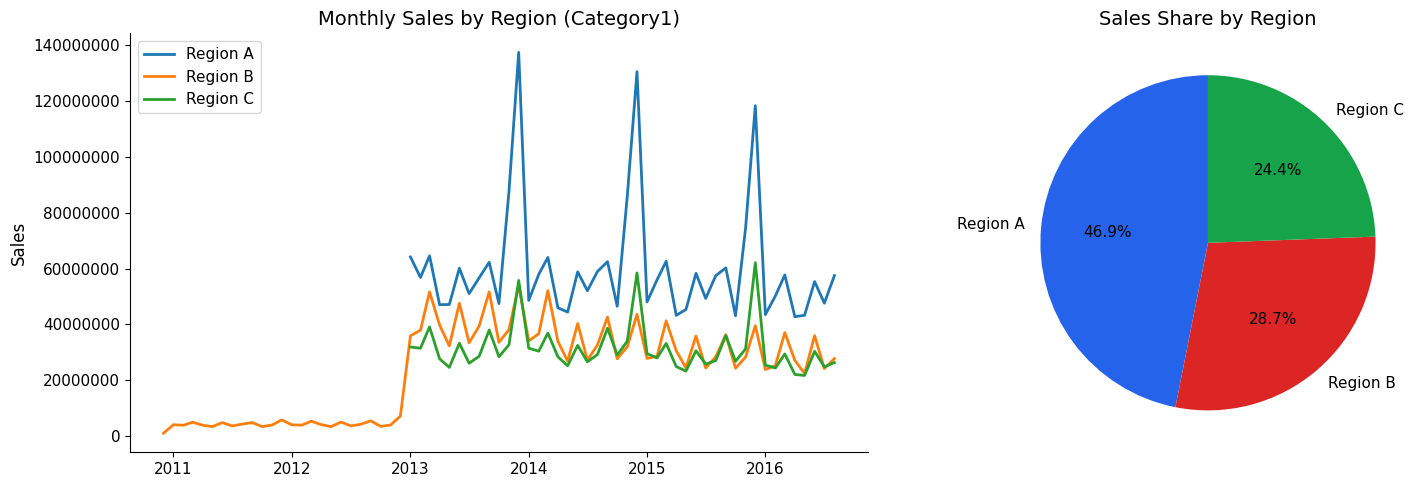

Total sales by Region:
  Region A: 2,653,394,463 (46.9%)
  Region B: 1,624,351,500 (28.7%)
  Region C: 1,381,417,847 (24.4%)


In [ ]:
# Category1 represents region (A, B, C)
# Category2 represents product group
# Category3 represents sub-category

# Aggregate by Category1 (Region)
region_sales = df_final.groupby(['Category1', 'date'])['sales'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series by region
for cat1 in sorted(region_sales['Category1'].unique()):
    s = region_sales[region_sales['Category1']==cat1]
    axes[0].plot(s['date'], s['sales'], label=f'Region {cat1}', linewidth=2)
axes[0].set_title('Monthly Sales by Region (Category1)')
axes[0].set_ylabel('Sales')
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='y')

# Total share by region
region_total = df_final.groupby('Category1')['sales'].sum()
axes[1].pie(region_total.values, labels=[f'Region {r}' for r in region_total.index],
            autopct='%1.1f%%', startangle=90, colors=['#2563eb', '#dc2626', '#16a34a'])
axes[1].set_title('Sales Share by Region')

plt.tight_layout()
plt.show()

print('Total sales by Region:')
for r, v in region_total.items():
    print(f'  Region {r}: {v:,.0f} ({v/region_total.sum()*100:.1f}%)')

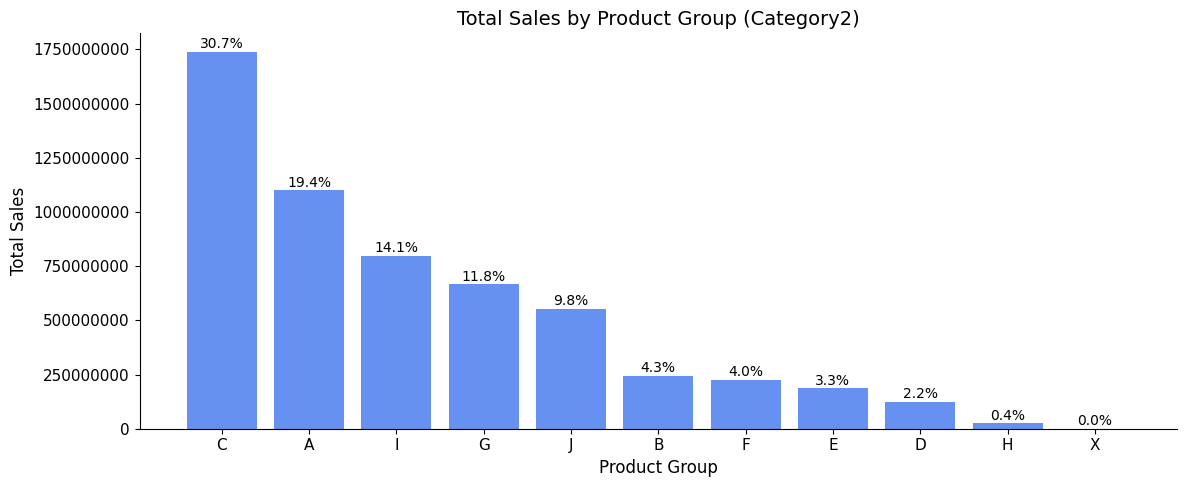

Product Group shares:
           total_sales  pct
Category2                  
C           1737370583   31
A           1099266205   19
I            796591387   14
G            666445882   12
J            552205433   10
B            245026375    4
F            226728519    4
E            185780089    3
D            124477709    2
H             24914310    0
X               357318    0


In [ ]:
# Aggregate by Category2 (Product Group)
group_total = summary_df.groupby('Category2')[['total_sales']].sum().sort_values('total_sales', ascending=False)
group_total['pct'] = (group_total['total_sales'] / group_total['total_sales'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(group_total.index, group_total['total_sales'], color='#2563eb', alpha=0.7)
ax.set_title('Total Sales by Product Group (Category2)')
ax.set_ylabel('Total Sales')
ax.set_xlabel('Product Group')
ax.ticklabel_format(style='plain', axis='y')

for bar, pct in zip(bars, group_total['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + group_total['total_sales'].max()*0.01,
            f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Product Group shares:')
print(group_total.to_string())

## 2.2 Top Product Categories — Time Series Visualization

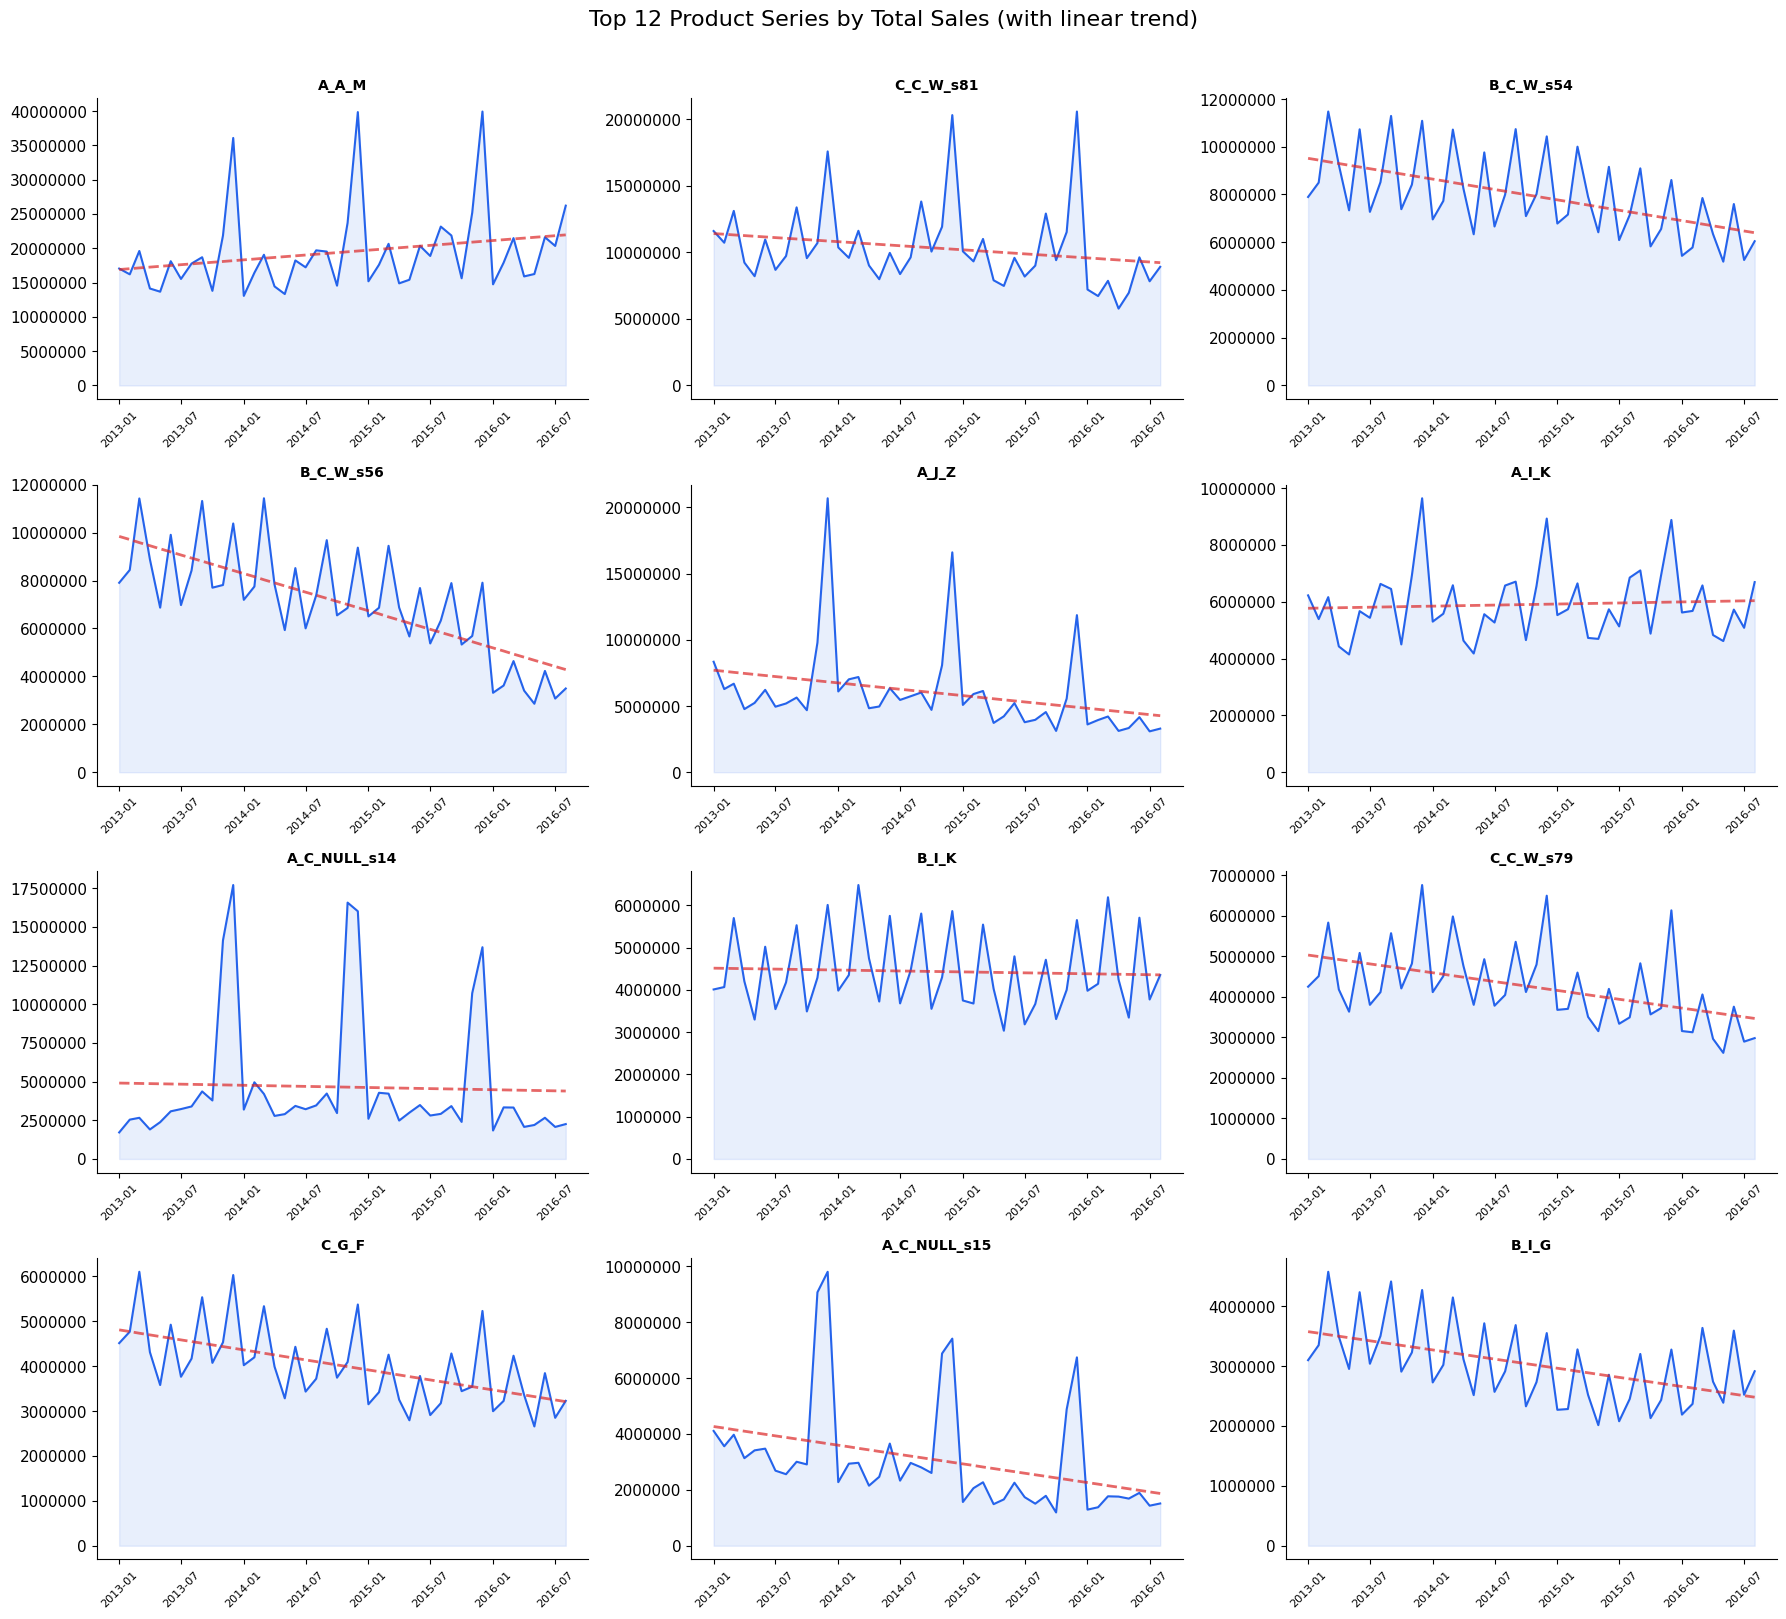

In [ ]:
# Plot top 12 series by total sales
top12 = summary_df.head(12)['series_label'].tolist()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, sl in enumerate(top12):
    s = df_final[df_final['series_label']==sl].sort_values('date')
    ax = axes[i]
    ax.plot(s['date'], s['sales'], color='#2563eb', linewidth=1.5)
    ax.fill_between(s['date'], s['sales'], alpha=0.1, color='#2563eb')
    ax.set_title(f'{sl}', fontsize=10, fontweight='bold')
    ax.ticklabel_format(style='plain', axis='y')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Add trend line
    x_num = np.arange(len(s))
    z = np.polyfit(x_num, s['sales'].values, 1)
    ax.plot(s['date'], np.polyval(z, x_num), color='#dc2626', linestyle='--', alpha=0.7)

plt.suptitle('Top 12 Product Series by Total Sales (with linear trend)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 2.3 Year-over-Year Growth Rates

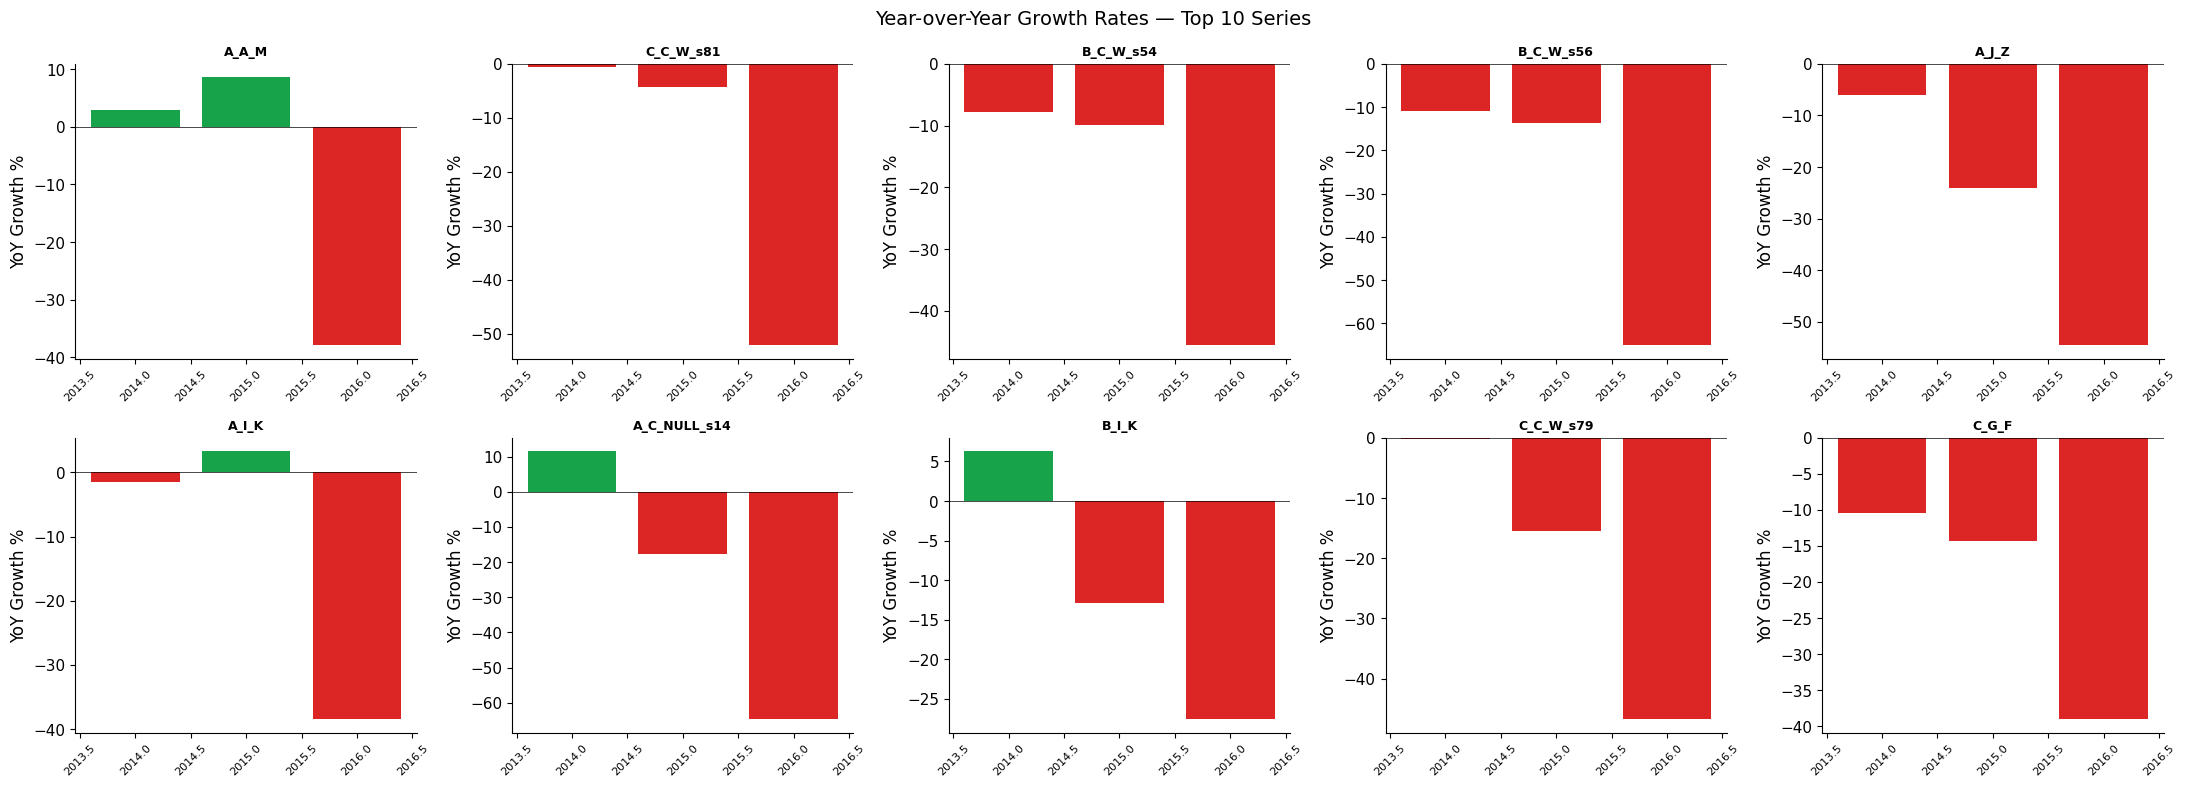

YoY Growth Rates (%) for Top 10 Series:
year          2014  2015  2016
series_label                  
A_A_M            3     9   -38
A_C_NULL_s14    12   -18   -65
A_I_K           -2     3   -38
A_J_Z           -6   -24   -54
B_C_W_s54       -8   -10   -46
B_C_W_s56      -11   -14   -65
B_I_K            6   -13   -28
C_C_W_s79       -0   -16   -47
C_C_W_s81       -1    -4   -52
C_G_F          -10   -14   -39


In [ ]:
# Calculate YoY growth for top series
df_final['year'] = df_final['date'].dt.year

# Annual sales by series
annual_series = df_final.groupby(['series_label', 'year'])['sales'].sum().reset_index()

# Focus on top 10 series
top10_series = summary_df.head(10)['series_label'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

growth_data = []
for i, sl in enumerate(top10_series):
    s = annual_series[annual_series['series_label']==sl].sort_values('year')
    ax = axes[i]

    yoy = s.set_index('year')['sales'].pct_change() * 100
    colors = ['#16a34a' if v > 0 else '#dc2626' for v in yoy.dropna().values]
    ax.bar(yoy.dropna().index, yoy.dropna().values, color=colors)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(sl, fontsize=9, fontweight='bold')
    ax.set_ylabel('YoY Growth %')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    for yr, val in yoy.dropna().items():
        growth_data.append({'series_label': sl, 'year': yr, 'yoy_growth': val})

plt.suptitle('Year-over-Year Growth Rates — Top 10 Series', fontsize=14)
plt.tight_layout()
plt.show()

growth_df = pd.DataFrame(growth_data)
growth_pivot = growth_df.pivot_table(index='series_label', columns='year', values='yoy_growth').round(1)
print('YoY Growth Rates (%) for Top 10 Series:')
print(growth_pivot.to_string())

## 2.4 Seasonality Patterns

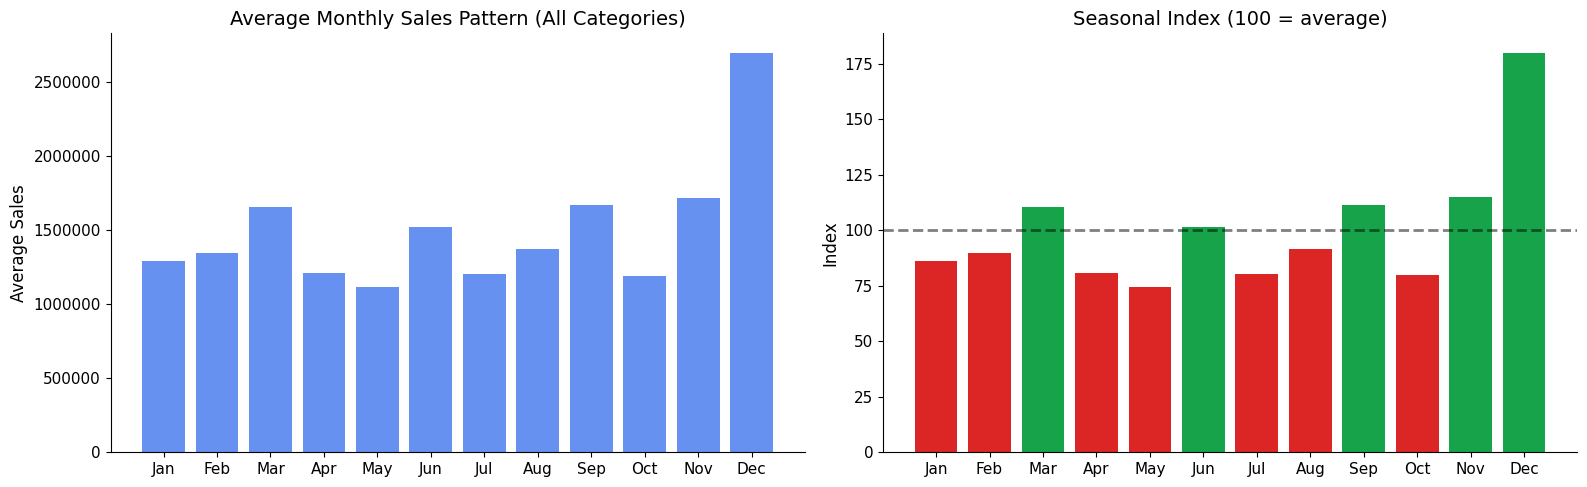

Seasonal Index by month:
  Jan: 86.2 ↓
  Feb: 89.8 ↓
  Mar: 110.5 ↑
  Apr: 80.8 ↓
  May: 74.3 ↓
  Jun: 101.3 ↑
  Jul: 80.4 ↓
  Aug: 91.7 ↓
  Sep: 111.2 ↑
  Oct: 79.6 ↓
  Nov: 114.7 ↑
  Dec: 179.6 ↑


In [ ]:
# Aggregate all sales by month to see overall seasonality
df_final['month'] = df_final['date'].dt.month
monthly_pattern = df_final.groupby('month')['sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall monthly pattern
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0].bar(range(1,13), monthly_pattern.values, color='#2563eb', alpha=0.7)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Average Monthly Sales Pattern (All Categories)')
axes[0].set_ylabel('Average Sales')
axes[0].ticklabel_format(style='plain', axis='y')

# Seasonal index (relative to mean)
seasonal_idx = (monthly_pattern / monthly_pattern.mean() * 100).round(1)
colors = ['#dc2626' if v < 100 else '#16a34a' for v in seasonal_idx]
axes[1].bar(range(1,13), seasonal_idx.values, color=colors)
axes[1].axhline(100, color='black', linestyle='--', alpha=0.5)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Seasonal Index (100 = average)')
axes[1].set_ylabel('Index')

plt.tight_layout()
plt.show()

print('Seasonal Index by month:')
for m, idx in seasonal_idx.items():
    direction = '↑' if idx > 100 else '↓'
    print(f'  {month_names[m-1]}: {idx:.1f} {direction}')

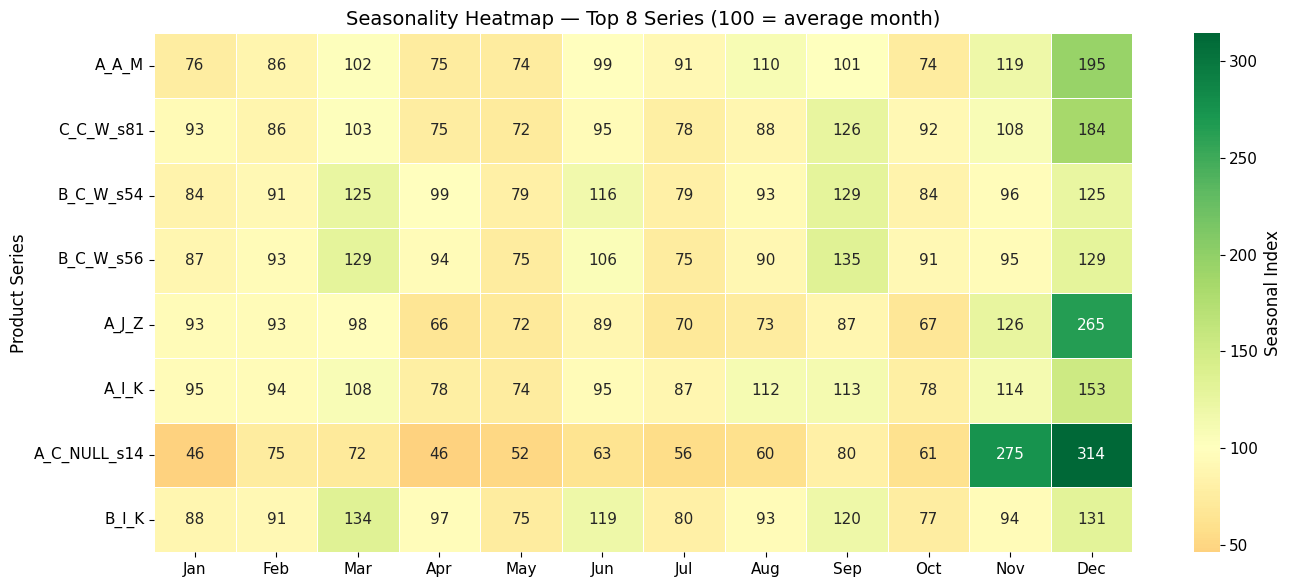

In [ ]:
# Seasonality heatmap for top series
top8_series = summary_df.head(8)['series_label'].tolist()

seasonal_matrix = []
for sl in top8_series:
    s = df_final[df_final['series_label']==sl]
    monthly_avg = s.groupby('month')['sales'].mean()
    seasonal_norm = (monthly_avg / monthly_avg.mean() * 100).round(1)
    seasonal_matrix.append(seasonal_norm)

seasonal_heat = pd.DataFrame(seasonal_matrix, index=top8_series)
seasonal_heat.columns = month_names[:len(seasonal_heat.columns)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(seasonal_heat, annot=True, fmt='.0f', cmap='RdYlGn', center=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Seasonal Index'})
ax.set_title('Seasonality Heatmap — Top 8 Series (100 = average month)')
ax.set_ylabel('Product Series')
plt.tight_layout()
plt.show()

## 2.5 Correlation Between Categories

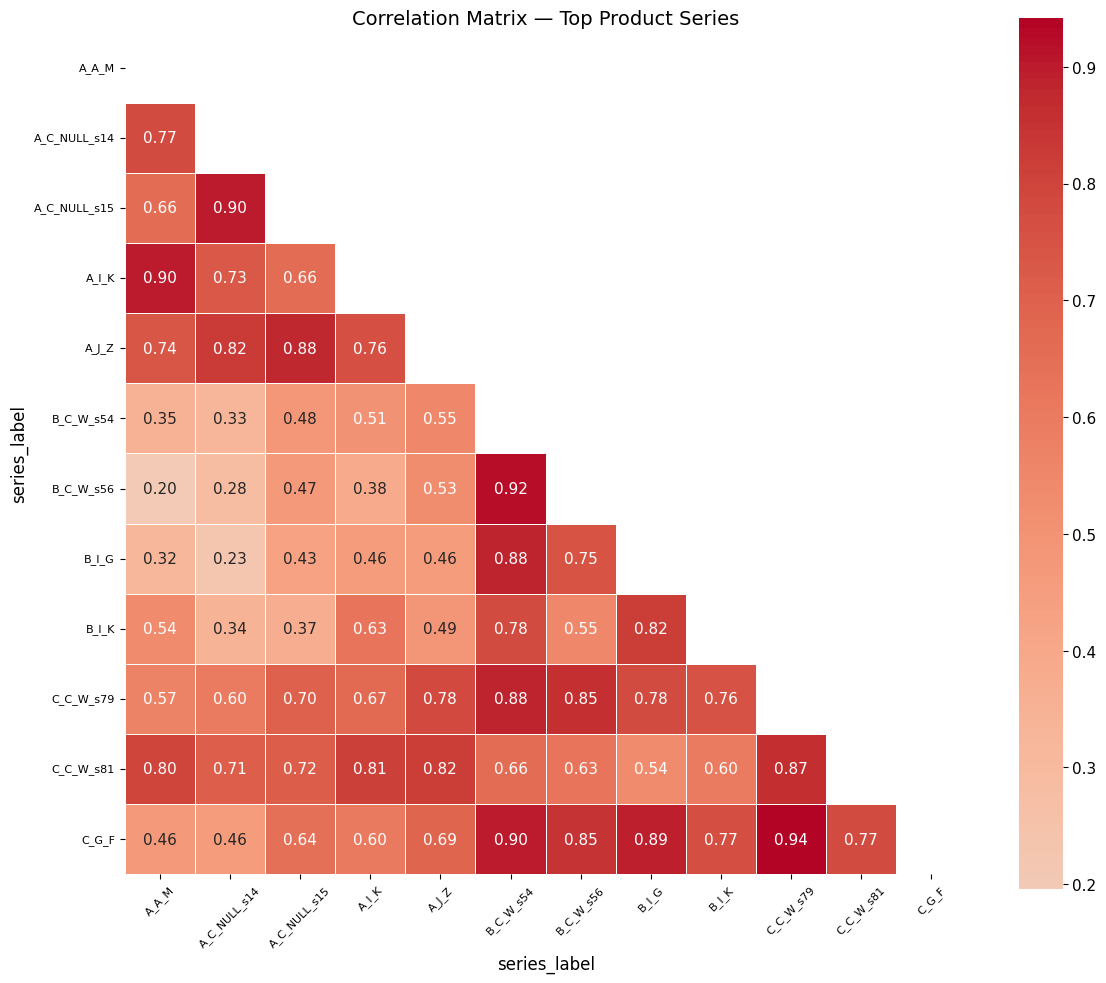

In [ ]:
# Create wide format for correlation (only series with full data)
top_for_corr = summary_df[summary_df['n_months'] >= 40].head(12)['series_label'].tolist()

wide_df = df_final[df_final['series_label'].isin(top_for_corr)].pivot_table(
    index='date', columns='series_label', values='sales')

fig, ax = plt.subplots(figsize=(12, 10))
corr = wide_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Top Product Series')
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

## 2.6 Key EDA Findings

| Finding | Detail |
|---------|--------|
| **Three regions** (A, B, C) | Different sales volumes; Region B often dominates |
| **Strong seasonality** | Clear December spike (holiday season), October/November buildup |
| **Mixed growth** | Some categories growing, others declining year-over-year |
| **Pareto distribution** | A few large categories dominate total sales |
| **Positive correlations** | Many top series move together (shared macro trends) |

---
# Part 3: Time Series Diagnostics

Before forecasting, we validate the statistical properties of each series. We forecast **all viable product series** with at least 36 months of history (3 full years — needed for seasonal pattern detection).

**Diagnostics performed:**
- **Stationarity tests**: ADF (tests for unit root) and KPSS (tests for trend-stationarity)  
- **Seasonal decomposition**: Additive decomposition to isolate trend, seasonal, and residual components  
- **ACF/PACF**: Identify autocorrelation structure for ARIMA order selection

> **Note on stationarity:** Models handle non-stationarity internally — SARIMAX uses the `d` and `D` differencing parameters, ETS uses trend components. We test stationarity to understand the data, not to manually difference before modeling.

In [ ]:
# Select ALL viable series for forecasting
# Criteria: >= 36 active months (need 3+ years for seasonal models)
forecast_candidates = summary_df[summary_df['n_months'] >= 36].sort_values('total_sales', ascending=False)

forecast_series = forecast_candidates['series_label'].tolist()

print(f'Selected {len(forecast_series)} series for forecasting (all with >= 36 months):')
print(f'{"="*80}')
for i, sl in enumerate(forecast_series, 1):
    row = summary_df[summary_df['series_label']==sl].iloc[0]
    print(f'  {i:2d}. {sl:25s}: {row["n_months"]} months, '
          f'avg={row["avg_monthly_sales"]:>12,.0f}, total={row["total_sales"]:>15,.0f} ({row["pct_total"]:.1f}%)')

# For diagnostics plots, show top 5 only (to keep notebook readable)
diag_series = forecast_series[:5]
print(f'\n(Showing diagnostics for top 5 series; forecasting all {len(forecast_series)})')

Selected 87 series for forecasting (all with >= 36 months):
   1. A_A_M                    : 44 months, avg=  19,428,236, total=    854,842,390 (15.1%)
   2. C_C_W_s81                : 44 months, avg=  10,309,516, total=    453,618,710 (8.0%)
   3. B_C_W_s54                : 44 months, avg=   7,956,510, total=    350,086,428 (6.2%)
   4. B_C_W_s56                : 44 months, avg=   7,064,435, total=    310,835,120 (5.5%)
   5. A_J_Z                    : 44 months, avg=   5,987,733, total=    263,460,272 (4.7%)
   6. A_I_K                    : 44 months, avg=   5,902,492, total=    259,709,643 (4.6%)
   7. A_C_NULL_s14             : 44 months, avg=   4,649,127, total=    204,561,587 (3.6%)
   8. B_I_K                    : 44 months, avg=   4,434,549, total=    195,120,144 (3.5%)
   9. C_C_W_s79                : 44 months, avg=   4,252,055, total=    187,090,403 (3.3%)
  10. C_G_F                    : 44 months, avg=   4,009,562, total=    176,420,725 (3.1%)
  11. A_C_NULL_s15           

## 3.1 Stationarity Tests (ADF & KPSS)

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

print('='*80)
print('STATIONARITY TESTS (All forecast candidates)')
print('='*80)

stationarity_results = []
for sl in forecast_series:
    s = df_final[df_final['series_label']==sl].sort_values('date')
    ts = s.set_index('date')['sales']

    # ADF Test (H0: non-stationary)
    adf_stat, adf_p, _, _, _, _ = adfuller(ts.dropna(), autolag='AIC')
    adf_result = 'Stationary' if adf_p < 0.05 else 'Non-stationary'

    # KPSS Test (H0: stationary) — suppress InterpolationWarning for short series
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, _, _ = kpss(ts.dropna(), regression='ct')
    kpss_result = 'Non-stationary' if kpss_p < 0.05 else 'Stationary'

    # First difference ADF
    adf_diff_stat, adf_diff_p, _, _, _, _ = adfuller(ts.diff().dropna(), autolag='AIC')
    adf_diff_result = 'Stationary' if adf_diff_p < 0.05 else 'Non-stationary'

    stationarity_results.append({
        'series_label': sl,
        'ADF_stat': adf_stat, 'ADF_p': adf_p, 'ADF_result': adf_result,
        'KPSS_stat': kpss_stat, 'KPSS_p': kpss_p, 'KPSS_result': kpss_result,
        'ADF_diff1_p': adf_diff_p, 'ADF_diff1_result': adf_diff_result,
    })

station_df = pd.DataFrame(stationarity_results)
print(station_df[['series_label', 'ADF_result', 'KPSS_result', 'ADF_diff1_result']].to_string(index=False))

print(f'\nSummary:')
print(f'  Stationary by ADF: {(station_df["ADF_result"]=="Stationary").sum()}/{len(station_df)}')
print(f'  Stationary by KPSS: {(station_df["KPSS_result"]=="Stationary").sum()}/{len(station_df)}')
print(f'  Stationary after 1st diff (ADF): {(station_df["ADF_diff1_result"]=="Stationary").sum()}/{len(station_df)}')

STATIONARITY TESTS (All forecast candidates)
series_label     ADF_result    KPSS_result ADF_diff1_result
       A_A_M     Stationary     Stationary       Stationary
   C_C_W_s81 Non-stationary     Stationary       Stationary
   B_C_W_s54 Non-stationary     Stationary       Stationary
   B_C_W_s56 Non-stationary     Stationary   Non-stationary
       A_J_Z     Stationary     Stationary       Stationary
       A_I_K     Stationary     Stationary       Stationary
A_C_NULL_s14 Non-stationary     Stationary       Stationary
       B_I_K Non-stationary     Stationary       Stationary
   C_C_W_s79 Non-stationary Non-stationary       Stationary
       C_G_F Non-stationary Non-stationary       Stationary
A_C_NULL_s15 Non-stationary     Stationary       Stationary
       B_I_G     Stationary Non-stationary   Non-stationary
    A_D_NULL Non-stationary     Stationary       Stationary
       B_A_N Non-stationary Non-stationary       Stationary
       B_G_H Non-stationary     Stationary       Statio

## 3.2 Seasonal Decomposition

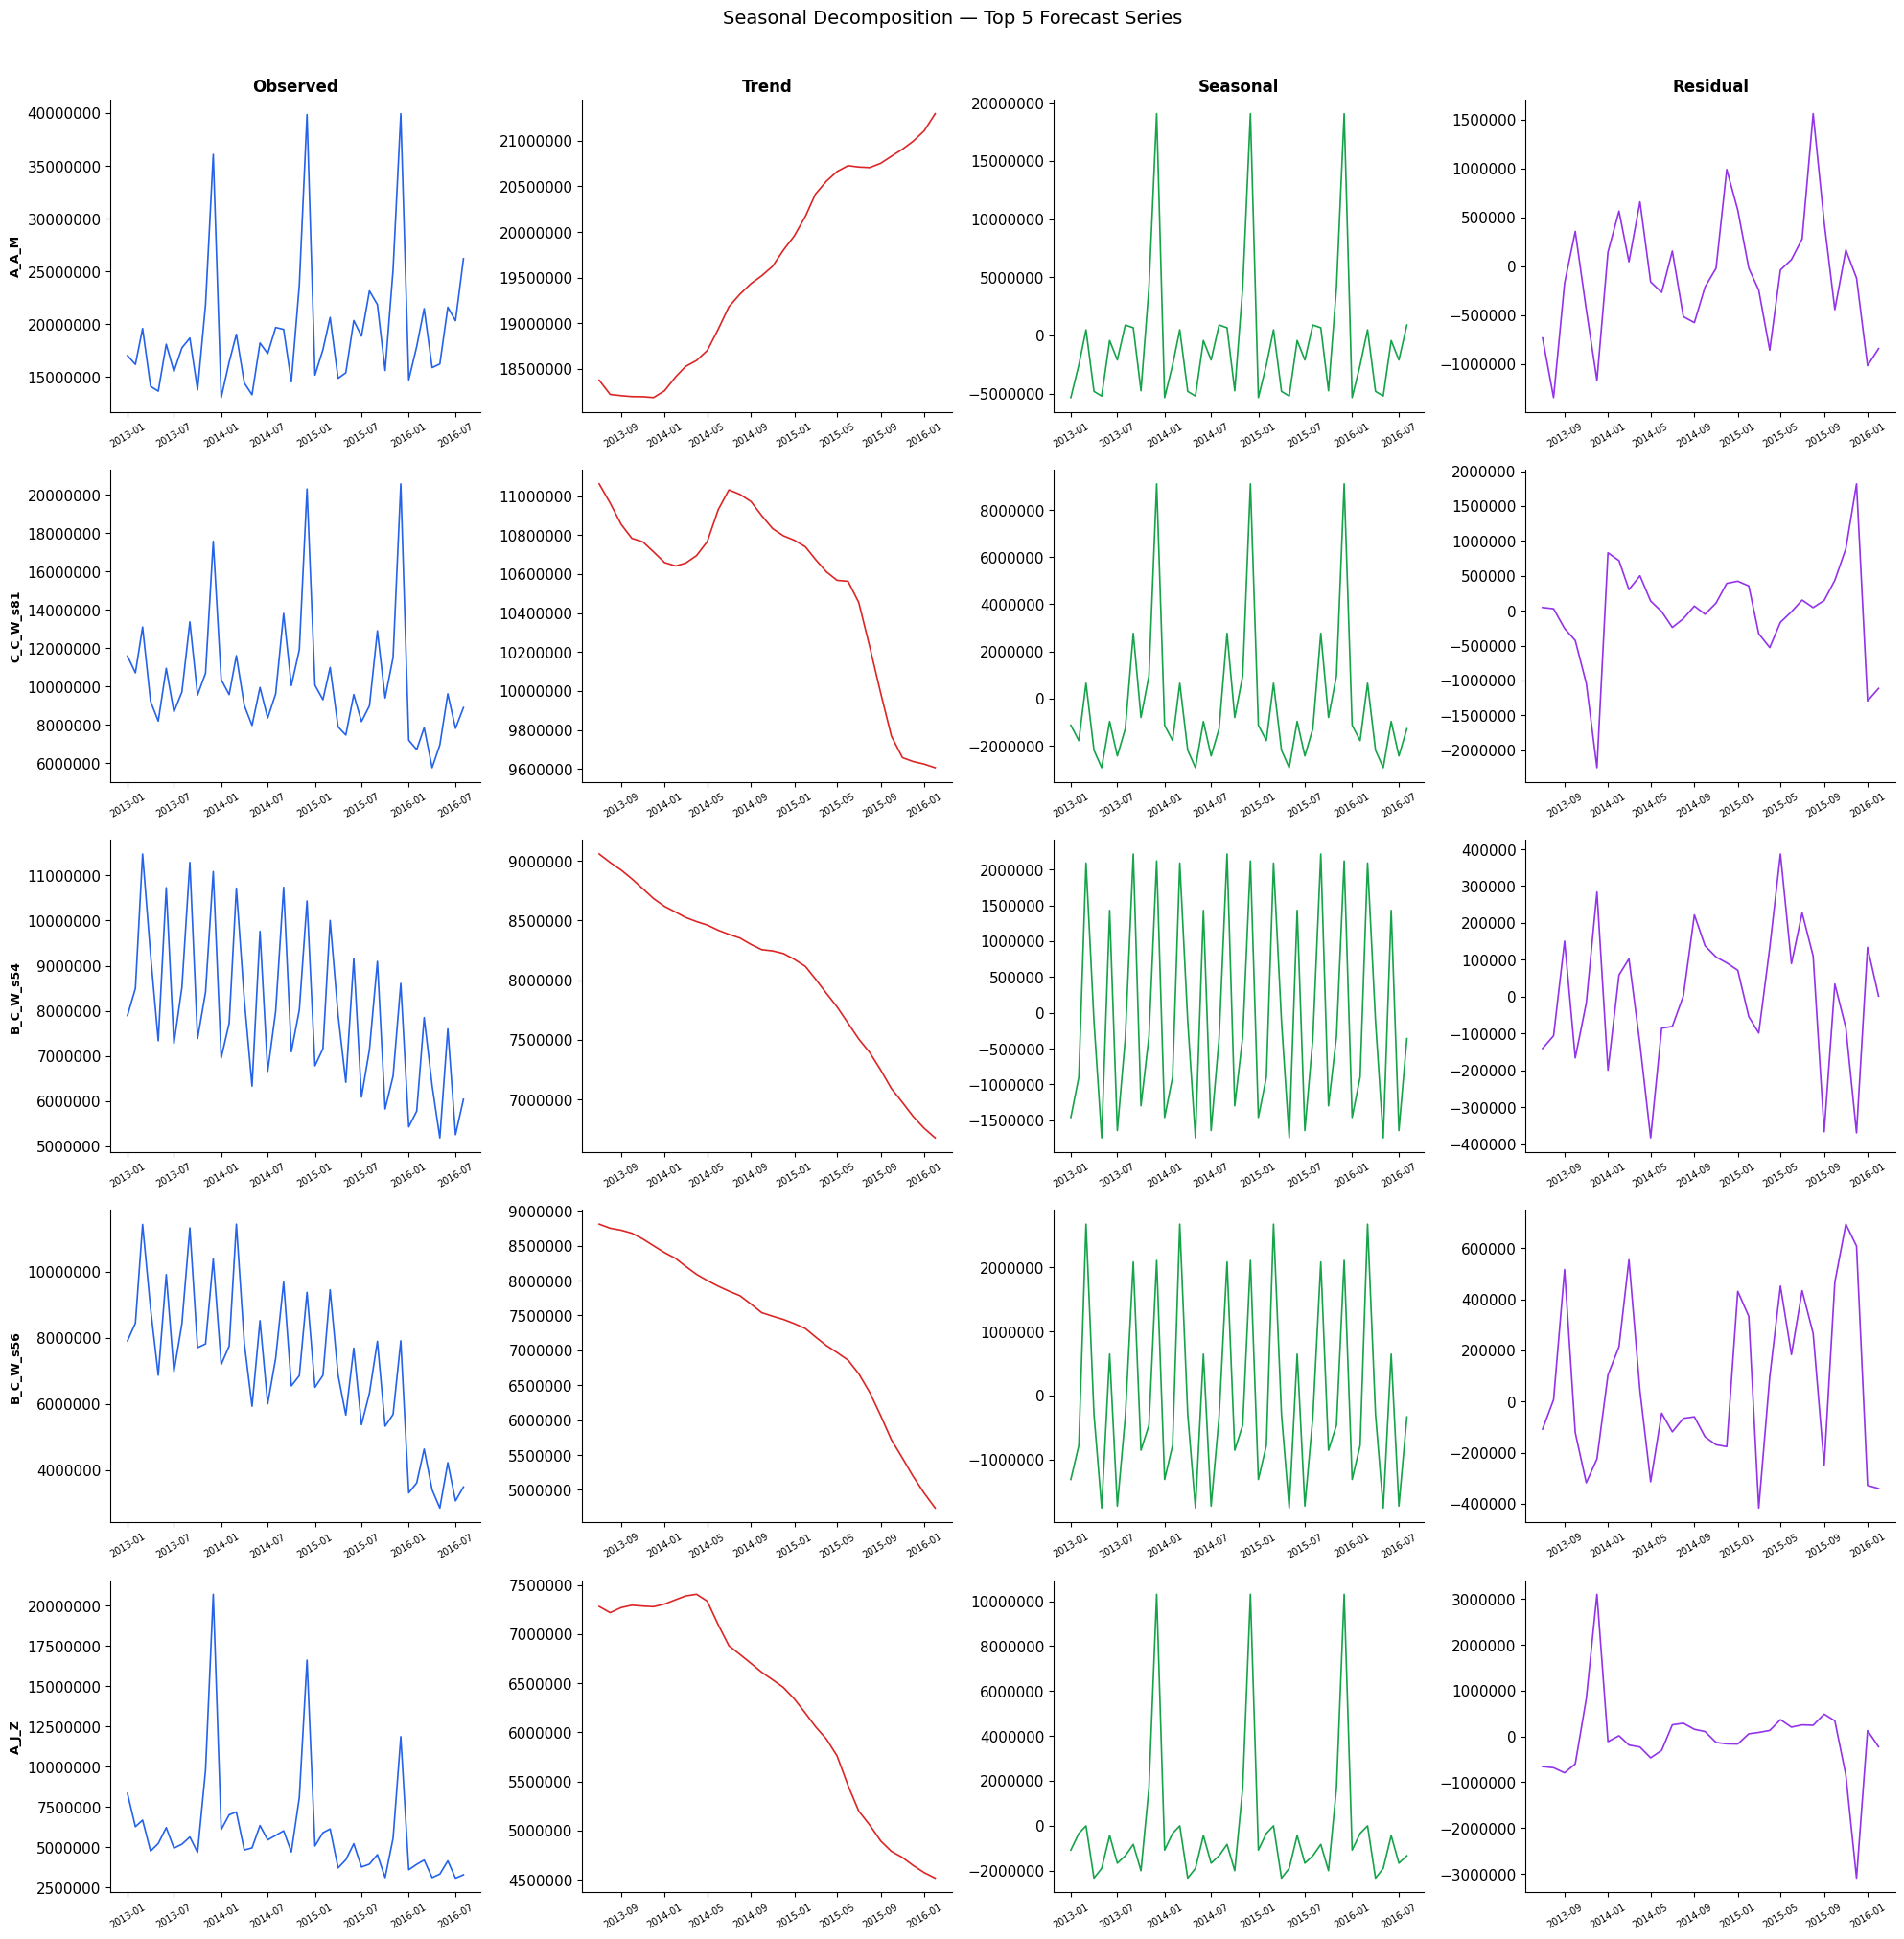

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(len(diag_series), 4, figsize=(20, 4*len(diag_series)))
if len(diag_series) == 1:
    axes = axes.reshape(1, -1)

for i, sl in enumerate(diag_series):
    s = df_final[df_final['series_label']==sl].sort_values('date')
    ts = s.set_index('date')['sales']
    ts = ts.asfreq('MS')
    ts = ts.fillna(method='ffill')

    decomp = seasonal_decompose(ts, model='additive', period=12)

    components = [('Observed', decomp.observed), ('Trend', decomp.trend),
                  ('Seasonal', decomp.seasonal), ('Residual', decomp.resid)]
    colors = ['#2563eb', '#dc2626', '#16a34a', '#9333ea']

    for j, ((title, data), color) in enumerate(zip(components, colors)):
        axes[i,j].plot(data.index, data.values, color=color, linewidth=1.2)
        if i == 0:
            axes[i,j].set_title(title, fontsize=12, fontweight='bold')
        axes[i,j].ticklabel_format(style='plain', axis='y')
        axes[i,j].tick_params(axis='x', rotation=30, labelsize=7)

    axes[i,0].set_ylabel(sl, fontsize=9, fontweight='bold')

plt.suptitle('Seasonal Decomposition — Top 5 Forecast Series', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3.3 ACF & PACF Analysis

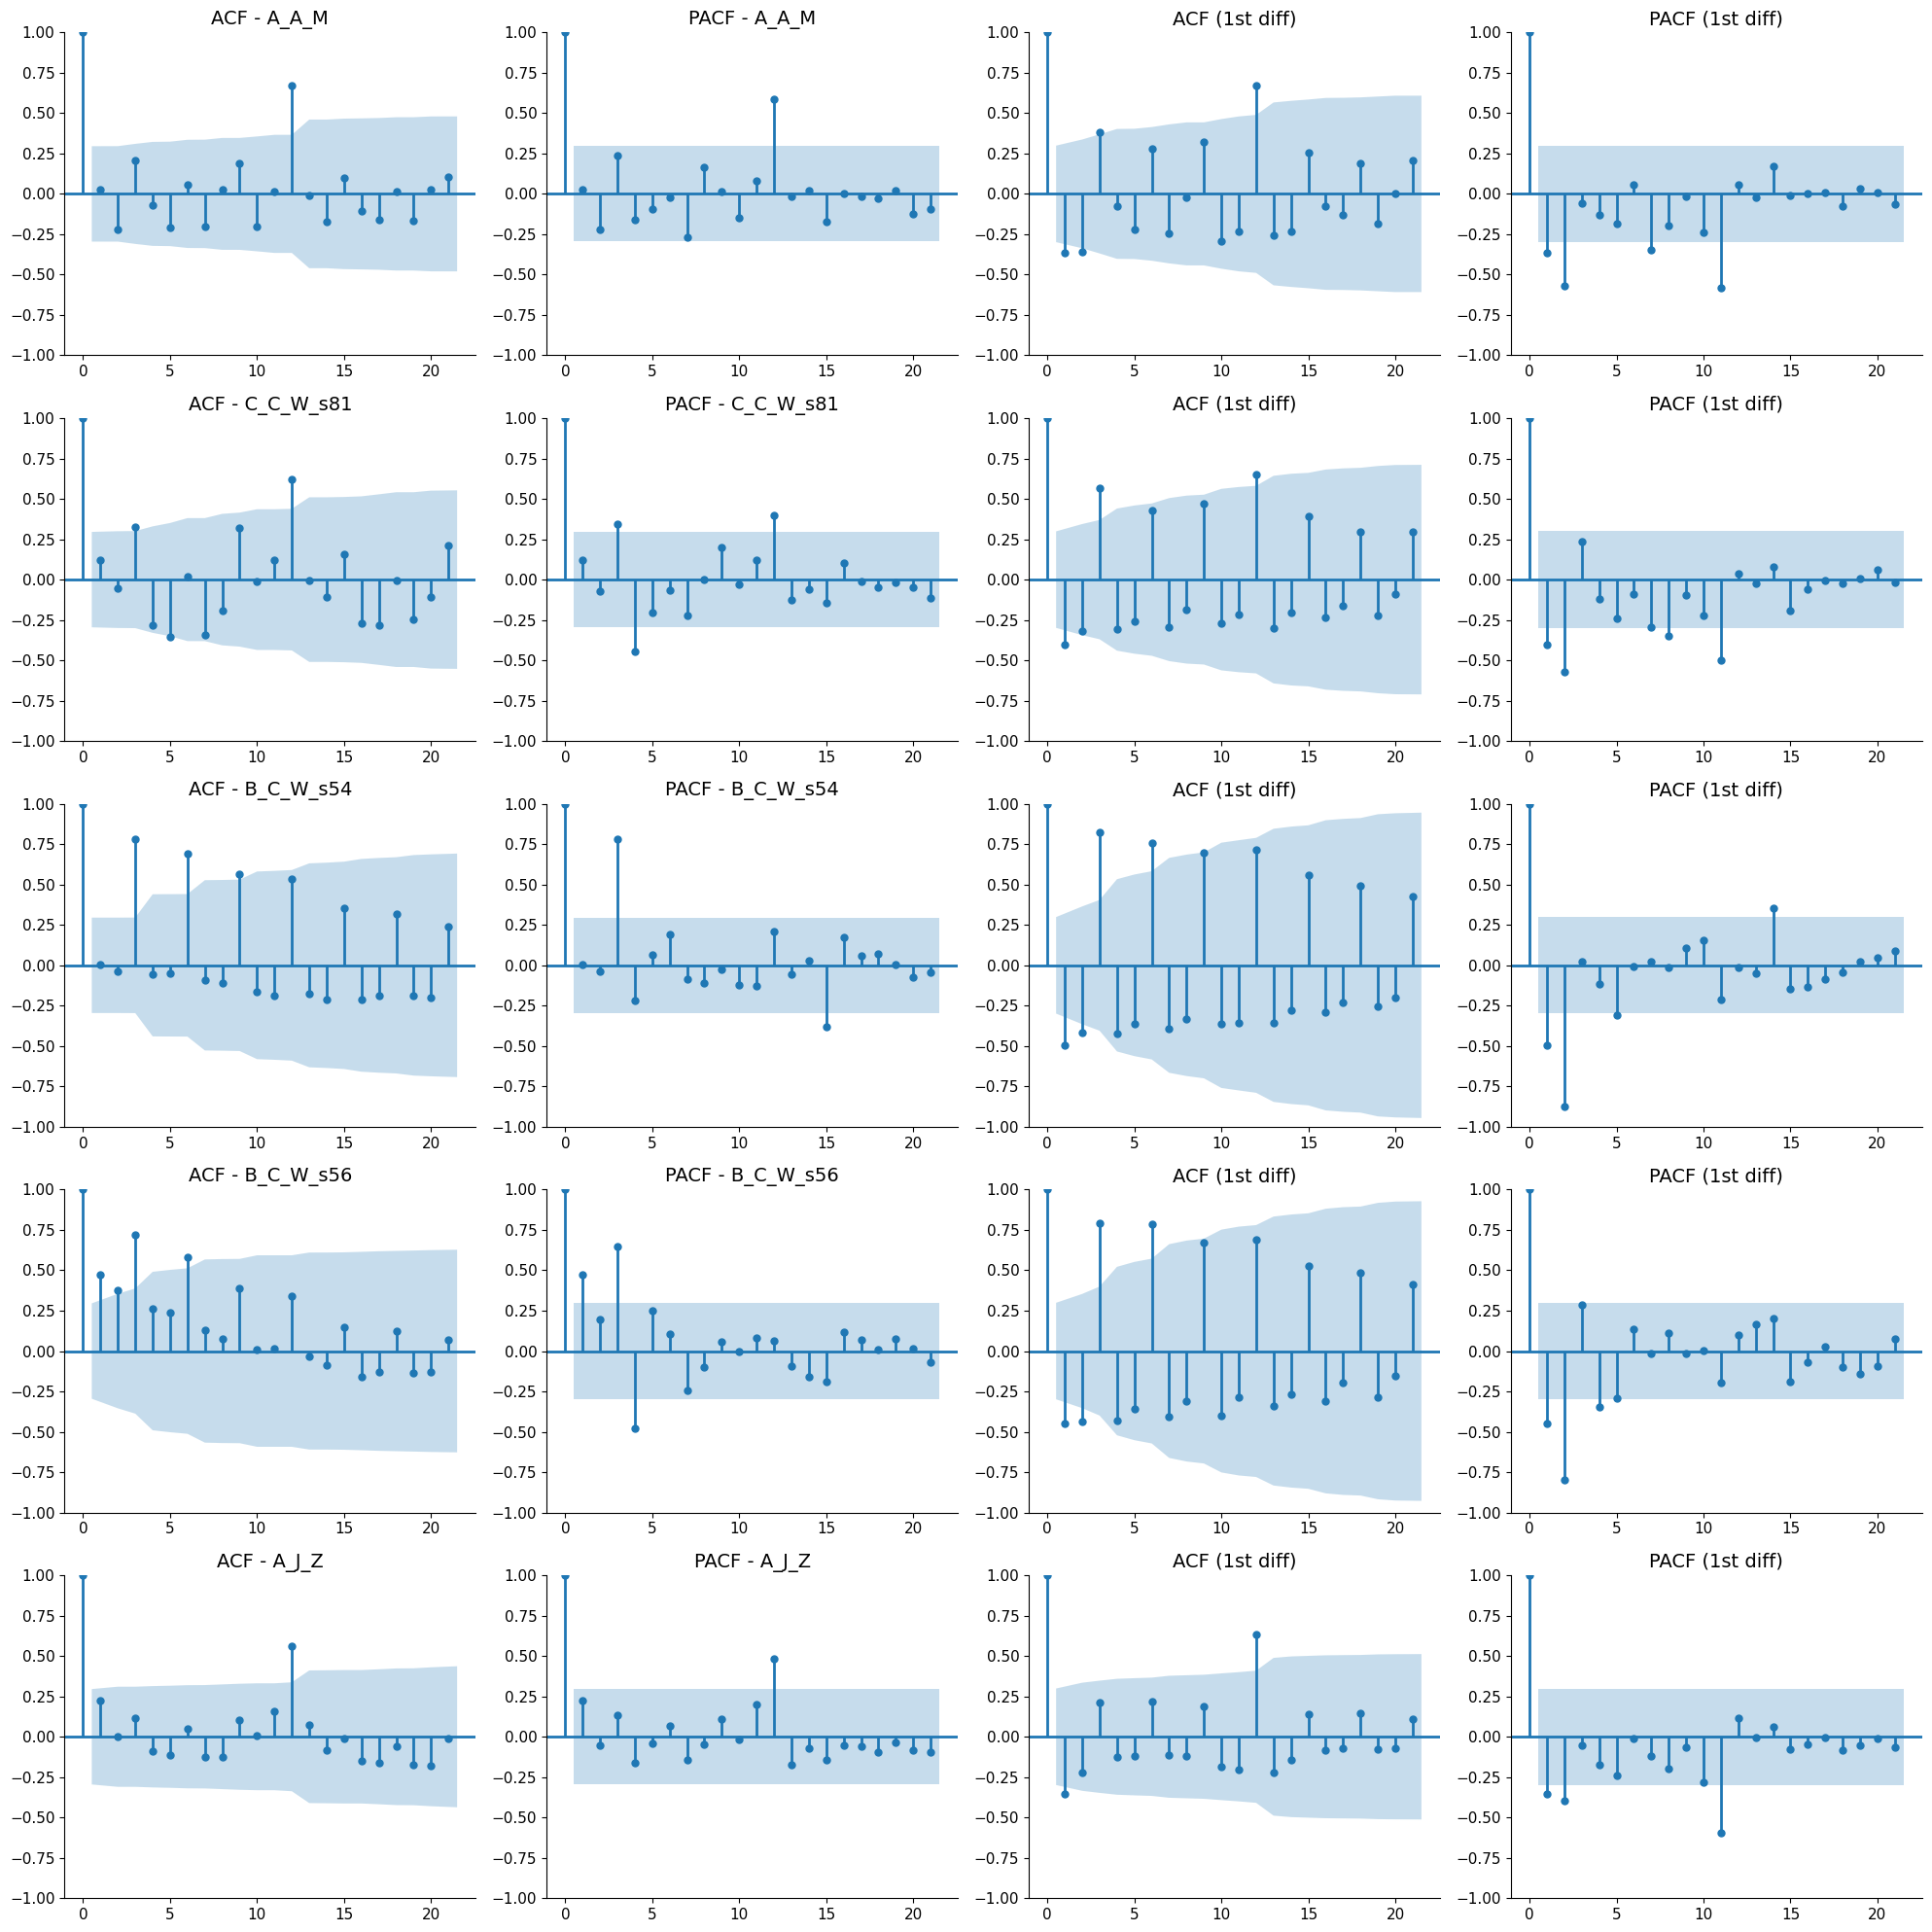

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(len(diag_series), 4, figsize=(20, 4*len(diag_series)))
if len(diag_series) == 1:
    axes = axes.reshape(1, -1)

for i, sl in enumerate(diag_series):
    s = df_final[df_final['series_label']==sl].sort_values('date')
    ts = s.set_index('date')['sales'].asfreq('MS').fillna(method='ffill')

    max_lags = min(30, len(ts)//2 - 1)

    plot_acf(ts, ax=axes[i,0], lags=max_lags, title=f'ACF - {sl}')
    plot_pacf(ts, ax=axes[i,1], lags=max_lags, title=f'PACF - {sl}')
    plot_acf(ts.diff().dropna(), ax=axes[i,2], lags=max_lags, title=f'ACF (1st diff)')
    plot_pacf(ts.diff().dropna(), ax=axes[i,3], lags=max_lags, title=f'PACF (1st diff)')

plt.tight_layout()
plt.show()

---
# Part 4: Forecasting All Product Series

We apply a comprehensive model comparison framework combining classical statistical models, Nixtla's automated models, machine learning, and baselines.

### Model Overview

| Family | Model | Library | Selection Method | Key Idea |
|--------|-------|---------|-----------------|----------|
| **Statistical** | SARIMAX | statsmodels | AIC on full series | Captures trend + seasonality via differencing |
| **Statistical** | Log-SARIMAX | statsmodels | AIC on full series | Variance stabilization via log transform |
| **Statistical** | ETS (Holt-Winters) | statsmodels | 2-fold expanding CV | Exponential smoothing with trend + seasonal |
| **Nixtla** | AutoARIMA | statsforecast | Automatic (Hyndman-Khandakar) | Automated ARIMA order selection |
| **Nixtla** | AutoETS | statsforecast | Automatic (information criteria) | Automated ETS model selection |
| **Nixtla** | AutoTheta | statsforecast | Automatic | Optimized Theta method (robust baseline) |
| **Nixtla** | AutoCES | statsforecast | Automatic (information criteria) | Complex Exponential Smoothing — captures cyclical patterns standard ETS misses |
| **Nixtla** | DynOptTheta | statsforecast | Automatic | Dynamic Optimized Theta — adapts parameters over time for evolving trends |
| **Nixtla** | OptTheta | statsforecast | Automatic | Optimized Theta — often outperforms standard Theta on short series |
| **Nixtla** | MSTL | statsforecast | Automatic | Multiple Seasonal-Trend decomposition — robust decomposition-based forecast |
| **ML** | Gradient Boosting | sklearn | 2-fold expanding CV | XGBoost-equivalent; learns non-linear lag patterns |
| **ML** | Random Forest | sklearn | 2-fold expanding CV | Ensemble of decision trees; robust to overfitting |
| **Baseline** | Seasonal Naive | — | 2-fold expanding CV | Repeats last 12 months |
| **Baseline** | Drift | — | 2-fold expanding CV | Seasonal Naive + linear trend adjustment |
| **Ensemble** | Average | — | — | Mean of best model from each family |

### Why AIC instead of BIC for SARIMAX?

Both AIC and BIC are information criteria that trade off model fit against complexity, but they differ in **how much they penalize extra parameters**:

| Criterion | Penalty per parameter | Behavior with small n |
|-----------|----------------------|----------------------|
| **AIC** | Fixed: 2 | More tolerant of complexity — favors models that capture real patterns |
| **BIC** | log(n) ≈ 3.8 for n=44 | Much harsher — aggressively favors simpler models |

We chose **AIC** for three reasons:

1. **Short series (n=44)**: With only ~3.5 annual cycles, BIC's heavier penalty often strips out seasonal components that are real but hard to detect statistically with few observations. AIC preserves them.
2. **Forecasting objective**: AIC is asymptotically equivalent to leave-one-out cross-validation error — it optimizes predictive accuracy. BIC is designed to identify the "true model" (consistent selection), which matters for inference but not for forecasting.
3. **Literature standard**: Hyndman & Athanasopoulos (*Forecasting: Principles and Practice*) recommend AIC/AICc for ARIMA/ETS model selection in forecasting applications. Nixtla's AutoARIMA also defaults to AIC internally.

Additionally, cross-validation is impractical for SARIMAX: with 44 months and a 12-month seasonal period, a 2-fold expanding window leaves only 20 months for training in fold 2 — insufficient for a seasonal ARIMA with 6+ parameters. AIC on the full series is more stable.

### Why 7 Nixtla Models?

[Nixtla's StatsForecast](https://nixtla.github.io/statsforecast/) provides production-grade implementations with automatic hyperparameter selection. We use 7 specialized models because each captures different aspects of the data:

- **AutoARIMA**: Best for series with strong autocorrelation (Hyndman-Khandakar algorithm)
- **AutoETS**: Best for series where level, trend, and seasonality interact multiplicatively
- **AutoTheta / OptimizedTheta**: Strong baselines that often win on short series where complex models overfit. OptimizedTheta optimizes the theta parameter rather than fixing it at 2
- **AutoCES**: Complex Exponential Smoothing uses complex-valued smoothing to capture cyclical dynamics that standard ETS misses — particularly useful for series with quasi-periodic patterns
- **DynamicOptimizedTheta**: Adapts its parameters over time rather than keeping them fixed — ideal for series with evolving trends (e.g., products gaining or losing market share)
- **MSTL**: Multiple Seasonal-Trend decomposition using LOESS — highly robust to outliers and structural breaks, and can handle multiple seasonal patterns simultaneously

By running all 7, we let each series "choose" which modeling approach works best. Some series respond better to ARIMA-style autocorrelation modeling, others to exponential smoothing, and others to decomposition-based approaches.

### ML Feature Engineering

The ML models use a rich feature set: 12 lag features, rolling statistics (mean 3/6/12, std 6), sin/cos calendar encoding, year-over-year sales, and recursive multi-step forecasting.

### Ensemble Strategy

The ensemble averages the best model from each family: SARIMAX, Log-SARIMAX, ETS, ML, plus selected Nixtla models (AutoARIMA, AutoCES, DynOptTheta, MSTL) and Seasonal Naive. This diversity-based approach reduces the risk of any single model's failure dominating the forecast.

## 4.1 Cross-Validation Framework

In [ ]:
def mape_score(y_true, y_pred):
    """MAPE with zero protection."""
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return float('inf')
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def ts_cv_rmse(full_series, model_fn, n_folds=2, val_size=12, min_train=24):
    """Expanding window time series cross-validation. Returns (RMSE, MAPE)."""
    rmses, mapes = [], []
    n = len(full_series)
    for fold in range(n_folds):
        val_end = n - fold * val_size
        val_start = val_end - val_size
        if val_start < min_train:
            break
        train_part = full_series.iloc[:val_start]
        val_part = full_series.iloc[val_start:val_end]
        try:
            fc = model_fn(train_part)
            if len(fc) >= val_size:
                fc = fc[:val_size]
            rmse = np.sqrt(mean_squared_error(val_part.values, fc))
            mape = mape_score(val_part.values, fc)
            rmses.append(rmse)
            mapes.append(mape)
        except:
            pass
    if rmses:
        return np.mean(rmses), np.mean(mapes)
    return float('inf'), float('inf')

def build_ml_features(series, n_lags=12):
    """Build lag-based features for ML forecasting from a time series."""
    df = pd.DataFrame({'y': series.values}, index=series.index)
    # Lag features
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    # Rolling statistics
    df['roll_mean_3'] = df['y'].shift(1).rolling(3).mean()
    df['roll_mean_6'] = df['y'].shift(1).rolling(6).mean()
    df['roll_mean_12'] = df['y'].shift(1).rolling(12).mean()
    df['roll_std_6'] = df['y'].shift(1).rolling(6).std()
    # Calendar features
    df['month'] = df.index.month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    # Year-over-year change
    df['yoy_change'] = df['y'].shift(12)
    return df.dropna()

print('Cross-validation framework + ML feature builder ready.')
print('Using expanding window CV with 12-month validation periods.')

Cross-validation framework + ML feature builder ready.
Using expanding window CV with 12-month validation periods.


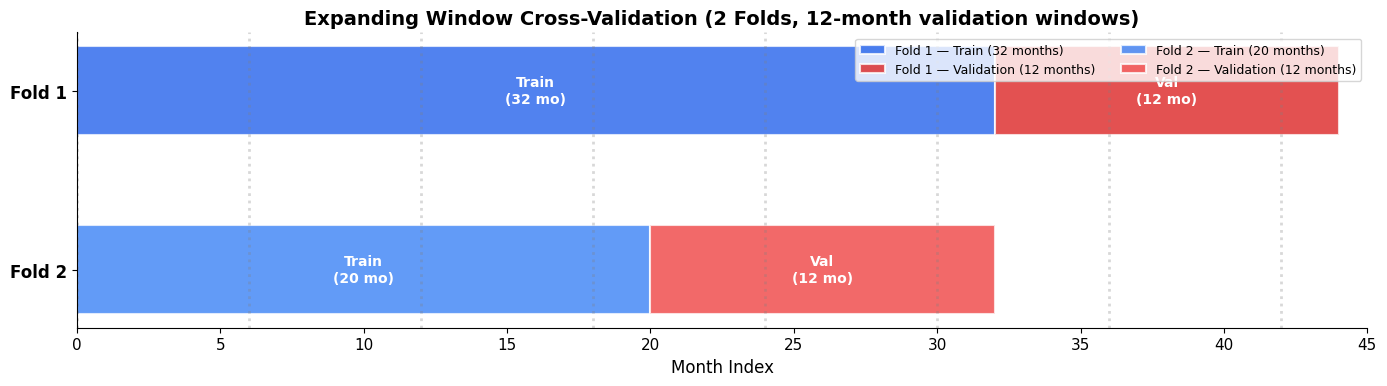

With 44-month series and 12-month validation windows:
  Fold 1: Train on months 1–32, validate on months 33–44
  Fold 2: Train on months 1–20, validate on months 21–32
  → Training set expands with each fold, mimicking real-world forecasting.


In [ ]:
# Visualize the Expanding Window Cross-Validation strategy
fig, ax = plt.subplots(figsize=(14, 4))

n_months = 44  # typical series length
val_size = 12
n_folds = 2
colors_train = ['#2563eb', '#3b82f6']
colors_val = ['#dc2626', '#ef4444']

y_positions = []
for fold in range(n_folds):
    val_end = n_months - fold * val_size
    val_start = val_end - val_size
    train_end = val_start
    y = n_folds - fold
    y_positions.append(y)

    # Training block
    ax.barh(y, train_end, left=0, height=0.5, color=colors_train[fold], alpha=0.8,
            edgecolor='white', linewidth=1.5, label=f'Fold {fold+1} — Train ({train_end} months)' if fold < n_folds else '')
    ax.text(train_end / 2, y, f'Train\n({train_end} mo)', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

    # Validation block
    ax.barh(y, val_size, left=val_start, height=0.5, color=colors_val[fold], alpha=0.8,
            edgecolor='white', linewidth=1.5, label=f'Fold {fold+1} — Validation ({val_size} months)' if fold < n_folds else '')
    ax.text(val_start + val_size / 2, y, f'Val\n({val_size} mo)', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

ax.set_yticks(y_positions)
ax.set_yticklabels([f'Fold {i+1}' for i in range(n_folds)], fontsize=12, fontweight='bold')
ax.set_xlabel('Month Index', fontsize=12)
ax.set_title('Expanding Window Cross-Validation (2 Folds, 12-month validation windows)', fontsize=14, fontweight='bold')
ax.set_xlim(0, n_months + 1)

# Add month markers
for m in range(0, n_months + 1, 6):
    ax.axvline(m, color='gray', linestyle=':', alpha=0.3)

ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

print('With 44-month series and 12-month validation windows:')
print('  Fold 1: Train on months 1–32, validate on months 33–44')
print('  Fold 2: Train on months 1–20, validate on months 21–32')
print('  → Training set expands with each fold, mimicking real-world forecasting.')

## 4.2 Forecasting Loop — All Selected Categories

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# SARIMAX parameter grid — focused set for efficiency with many series
# Reduced from 144 to 36 configs, covering the most common effective orders
p_range, d_range, q_range = [0,1,2], [0,1], [0,1,2]
P_range, D_range, Q_range = [0,1], [0,1], [0,1]
s = 12

# Full grid for reference
sarimax_full = list(iterproduct(p_range, d_range, q_range, P_range, D_range, Q_range))

# Focused grid: most effective SARIMAX orders from literature + group project
sarimax_configs = [
    (0,1,1, 0,1,1), (0,1,1, 1,1,1), (0,1,2, 0,1,1), (0,1,2, 1,1,1),
    (1,1,1, 0,1,1), (1,1,1, 1,1,1), (1,1,2, 0,1,1), (1,1,2, 1,1,1),
    (2,1,1, 0,1,1), (2,1,1, 1,1,1), (2,1,2, 0,1,1), (2,1,2, 1,1,1),
    (0,0,1, 1,0,1), (0,0,2, 1,0,1), (1,0,0, 1,0,0), (1,0,1, 1,0,0),
    (1,0,1, 1,0,1), (2,0,0, 1,0,0), (2,0,1, 1,0,0), (2,0,1, 1,0,1),
    (0,1,0, 1,0,0), (0,1,0, 0,1,1), (1,0,0, 0,1,1), (1,1,0, 0,1,1),
]
print(f'SARIMAX configurations per series: {len(sarimax_configs)} (focused grid)')

# ETS configurations
ets_configs = [
    ('add', False, 'add', 'ETS(A,A,A)'), ('add', True, 'add', 'ETS(A,Ad,A)'),
    ('mul', False, 'add', 'ETS(A,M,A)'), ('mul', True, 'add', 'ETS(A,Md,A)'),
    ('add', False, 'mul', 'ETS(M,A,M)'), ('add', True, 'mul', 'ETS(M,Ad,M)'),
    ('mul', False, 'mul', 'ETS(M,M,M)'), ('mul', True, 'mul', 'ETS(M,Md,M)'),
    (None, False, 'add', 'ETS(A,N,A)'), (None, False, 'mul', 'ETS(M,N,M)'),
]

print(f'ETS configurations per series: {len(ets_configs)}')

SARIMAX configurations per series: 24 (focused grid)
ETS configurations per series: 10


In [ ]:
import warnings
warnings.filterwarnings('ignore')

all_forecasts = {}   # {series_label: {model_name: forecast_array}}
all_rankings = {}    # {series_label: DataFrame with model rankings}
all_best_models = {} # {series_label: {best_model, rmse, mape}}

def ml_recursive_forecast(model, ts, n_lags=12, horizon=12):
    """Generate recursive multi-step ML forecast."""
    history = list(ts.values)
    preds = []
    for step in range(horizon):
        future_month = ts.index[-1] + pd.DateOffset(months=step+1)
        row = {}
        for lag in range(1, n_lags+1):
            idx = len(history) - lag
            row[f'lag_{lag}'] = history[idx] if idx >= 0 else 0
        row['roll_mean_3'] = np.mean(history[-3:]) if len(history) >= 3 else np.mean(history)
        row['roll_mean_6'] = np.mean(history[-6:]) if len(history) >= 6 else np.mean(history)
        row['roll_mean_12'] = np.mean(history[-12:]) if len(history) >= 12 else np.mean(history)
        row['roll_std_6'] = np.std(history[-6:]) if len(history) >= 6 else np.std(history)
        row['month_sin'] = np.sin(2 * np.pi * future_month.month / 12)
        row['month_cos'] = np.cos(2 * np.pi * future_month.month / 12)
        row['yoy_change'] = history[-12] if len(history) >= 12 else history[0]

        X_pred = pd.DataFrame([row])
        pred = model.predict(X_pred)[0]
        pred = max(pred, 0)
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

def run_nixtla_forecast(ts, series_label):
    """Run 7 Nixtla StatsForecast models on a single series.

    Models: AutoARIMA, AutoETS, AutoTheta, AutoCES,
            DynamicOptimizedTheta, OptimizedTheta, MSTL
    """
    sf_df = pd.DataFrame({
        'unique_id': np.zeros(len(ts), dtype=np.float64),
        'ds': ts.index,
        'y': ts.values.astype(np.float64)
    })
    sf = StatsForecast(
        models=[
            AutoARIMA(season_length=12),
            NixtlaAutoETS(season_length=12),
            AutoTheta(season_length=12),
            AutoCES(season_length=12),
            DynamicOptimizedTheta(season_length=12),
            OptimizedTheta(season_length=12),
            MSTL(season_length=12),
        ],
        freq='MS', n_jobs=1
    )
    sf.fit(sf_df)
    fc = sf.predict(h=12)
    return {
        'AutoARIMA': fc['AutoARIMA'].values,
        'AutoETS': fc['AutoETS'].values,
        'AutoTheta': fc['AutoTheta'].values,
        'AutoCES': fc['CES'].values,                          # Column name is 'CES', not 'AutoCES'
        'DynOptTheta': fc['DynamicOptimizedTheta'].values,
        'OptTheta': fc['OptimizedTheta'].values,
        'MSTL': fc['MSTL'].values,
    }

def nixtla_cv_single(ts, model_name, n_folds=2, val_size=12, min_train=24):
    """Run expanding-window CV for a single Nixtla model. Returns (RMSE, MAPE)."""
    # Map short names to model constructors
    model_map = {
        'AutoARIMA': lambda: AutoARIMA(season_length=12),
        'AutoETS': lambda: NixtlaAutoETS(season_length=12),
        'AutoTheta': lambda: AutoTheta(season_length=12),
        'AutoCES': lambda: AutoCES(season_length=12),
        'DynOptTheta': lambda: DynamicOptimizedTheta(season_length=12),
        'OptTheta': lambda: OptimizedTheta(season_length=12),
        'MSTL': lambda: MSTL(season_length=12),
    }
    rmses, mapes = [], []
    n = len(ts)
    for fold in range(n_folds):
        val_end = n - fold * val_size
        val_start = val_end - val_size
        if val_start < min_train:
            break
        train_part = ts.iloc[:val_start]
        val_part = ts.iloc[val_start:val_end]
        try:
            sf_df = pd.DataFrame({
                'unique_id': np.zeros(len(train_part), dtype=np.float64),
                'ds': train_part.index,
                'y': train_part.values.astype(np.float64)
            })
            sf = StatsForecast(models=[model_map[model_name]()], freq='MS', n_jobs=1)
            sf.fit(sf_df)
            fc = sf.predict(h=val_size)
            # Get the forecast column (first non-ds, non-unique_id column)
            fc_cols = [c for c in fc.columns if c not in ('ds', 'unique_id')]
            fc_vals = fc[fc_cols[0]].values
            if np.all(np.isfinite(fc_vals)):
                rmse = np.sqrt(mean_squared_error(val_part.values, fc_vals))
                mape = mape_score(val_part.values, fc_vals)
                rmses.append(rmse)
                mapes.append(mape)
        except:
            pass
    if rmses:
        return np.mean(rmses), np.mean(mapes)
    return float('inf'), float('inf')

for s_idx, sl in enumerate(forecast_series):
    print(f'\n{"="*70}')
    print(f'SERIES {s_idx+1}/{len(forecast_series)}: {sl}')
    print(f'{"="*70}')

    s_data = df_final[df_final['series_label']==sl].sort_values('date')
    ts = s_data.set_index('date')['sales'].asfreq('MS').fillna(method='ffill')
    print(f'Length: {len(ts)} months, Mean: {ts.mean():,.0f}, Std: {ts.std():,.0f}')

    scale_factor = max(ts.mean() / 1000, 1)
    results = []
    forecasts = {}

    # ================================================================
    # 1. SARIMAX (AIC-based)
    # ================================================================
    sarimax_res = []
    for (p, d, q, P, D, Q) in sarimax_configs:
        order, seasonal = (p,d,q), (P,D,Q,s)
        try:
            m = SARIMAX(ts / scale_factor, order=order, seasonal_order=seasonal,
                        enforce_stationarity=False, enforce_invertibility=False)
            fit = m.fit(disp=False, maxiter=300)
            fc = fit.forecast(12).values * scale_factor
            if np.all(np.isfinite(fc)) and np.all(fc > 0) and np.all(fc < ts.max() * 10):
                sarimax_res.append({'order': order, 'seasonal': seasonal, 'aic': fit.aic, 'forecast': fc})
        except:
            pass
    sarimax_res.sort(key=lambda x: x['aic'])
    if sarimax_res:
        best = sarimax_res[0]
        name = f'SARIMAX{best["order"]}x{best["seasonal"]}'
        results.append({'Model': name, 'CV_RMSE': float('nan'), 'MAPE': float('nan'), 'AIC': best['aic'], 'Type': 'SARIMAX'})
        forecasts['Best_SARIMAX'] = best['forecast']
        print(f'  SARIMAX: {name} (AIC={best["aic"]:.1f})')

    # ================================================================
    # 2. Log-SARIMAX (AIC-based)
    # ================================================================
    log_res = []
    ts_pos = ts.copy(); ts_pos[ts_pos <= 0] = 1
    for (p, d, q, P, D, Q) in sarimax_configs:
        order, seasonal = (p,d,q), (P,D,Q,s)
        try:
            m = SARIMAX(np.log(ts_pos / scale_factor), order=order, seasonal_order=seasonal,
                        enforce_stationarity=False, enforce_invertibility=False)
            fit = m.fit(disp=False, maxiter=300)
            fc = np.exp(fit.forecast(12).values) * scale_factor
            if np.all(np.isfinite(fc)) and np.all(fc > 0) and np.all(fc < ts.max() * 10):
                log_res.append({'order': order, 'seasonal': seasonal, 'aic': fit.aic, 'forecast': fc})
        except:
            pass
    log_res.sort(key=lambda x: x['aic'])
    if log_res:
        best = log_res[0]
        name = f'LogSARIMAX{best["order"]}x{best["seasonal"]}'
        results.append({'Model': name, 'CV_RMSE': float('nan'), 'MAPE': float('nan'), 'AIC': best['aic'], 'Type': 'LogSARIMAX'})
        forecasts['Best_LogSARIMAX'] = best['forecast']
        print(f'  LogSARIMAX: {name} (AIC={best["aic"]:.1f})')

    # ================================================================
    # 3. ETS Models (CV-based)
    # ================================================================
    for trend, damped, seasonal_type, name in ets_configs:
        def make_ets(t, d, ss):
            def fn(tr):
                m = ExponentialSmoothing(tr, trend=t, damped_trend=d, seasonal=ss, seasonal_periods=12)
                return m.fit(optimized=True).forecast(12).values
            return fn
        try:
            cv_rmse, cv_mape = ts_cv_rmse(ts, make_ets(trend, damped, seasonal_type), n_folds=2)
            results.append({'Model': name, 'CV_RMSE': cv_rmse, 'MAPE': cv_mape, 'AIC': float('nan'), 'Type': 'ETS'})
        except:
            pass

    # ================================================================
    # 4. Nixtla StatsForecast (7 models — with CV evaluation)
    # ================================================================
    nixtla_names = ['AutoARIMA', 'AutoETS', 'AutoTheta', 'AutoCES', 'DynOptTheta', 'OptTheta', 'MSTL']
    nixtla_cv_count = 0
    for nx_name in nixtla_names:
        try:
            cv_rmse, cv_mape = nixtla_cv_single(ts, nx_name, n_folds=2)
            if cv_rmse < float('inf'):
                results.append({'Model': f'Nixtla_{nx_name}', 'CV_RMSE': cv_rmse, 'MAPE': cv_mape,
                                'AIC': float('nan'), 'Type': 'Nixtla'})
                nixtla_cv_count += 1
        except:
            pass
    print(f'  Nixtla CV: {nixtla_cv_count}/7 models evaluated')

    # Generate final Nixtla forecasts (fit on full series)
    try:
        nixtla_fc = run_nixtla_forecast(ts, sl)
        for nx_name, nx_vals in nixtla_fc.items():
            if np.all(np.isfinite(nx_vals)):
                forecasts[f'Nixtla_{nx_name}'] = nx_vals
    except Exception as e:
        print(f'  Nixtla forecast error: {e}')

    # ================================================================
    # 5. ML Models: GradientBoosting + RandomForest (CV-based)
    # ================================================================
    ml_models = [
        ('GradientBoosting', GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
        ('RandomForest', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)),
    ]

    for ml_name, ml_model in ml_models:
        def make_ml_fn(model_template, ml_nm):
            def fn(tr):
                feat_df = build_ml_features(tr)
                if len(feat_df) < 15:
                    return None
                X = feat_df.drop(columns=['y', 'month'])
                y = feat_df['y']
                from sklearn.base import clone
                model = clone(model_template)
                model.fit(X, y)
                return ml_recursive_forecast(model, tr, n_lags=12, horizon=12)
            return fn
        try:
            cv_rmse, cv_mape = ts_cv_rmse(ts, make_ml_fn(ml_model, ml_name), n_folds=2)
            if cv_rmse < float('inf'):
                results.append({'Model': ml_name, 'CV_RMSE': cv_rmse, 'MAPE': cv_mape, 'AIC': float('nan'), 'Type': 'ML'})
                print(f'  {ml_name}: CV RMSE={cv_rmse:,.0f}, MAPE={cv_mape:.1f}%')
        except:
            pass

    # ================================================================
    # 6. Baselines (CV-based)
    # ================================================================
    def seasonal_naive(tr): return tr.values[-12:]
    cv_rmse, cv_mape = ts_cv_rmse(ts, seasonal_naive, n_folds=2)
    results.append({'Model': 'SeasonalNaive', 'CV_RMSE': cv_rmse, 'MAPE': cv_mape, 'AIC': float('nan'), 'Type': 'Baseline'})

    def drift_model(tr, frac=0.5):
        last = tr.values[-12:]
        prev = tr.values[-24:-12]
        return last + (last - prev) * frac

    for frac in [0.25, 0.50, 0.75]:
        fn = lambda tr, f=frac: drift_model(tr, f)
        cv_rmse, cv_mape = ts_cv_rmse(ts, fn, n_folds=2)
        results.append({'Model': f'Drift_{int(frac*100)}pct', 'CV_RMSE': cv_rmse, 'MAPE': cv_mape, 'AIC': float('nan'), 'Type': 'Baseline'})

    # ================================================================
    # Ranking — ALL CV-evaluated models compete (ETS, Nixtla, ML, Baseline)
    # ================================================================
    cv_results = [r for r in results if r['Type'] in ('ETS', 'Nixtla', 'Baseline', 'ML')]
    ranking = pd.DataFrame(cv_results).sort_values('CV_RMSE').reset_index(drop=True)
    ranking.index = ranking.index + 1
    all_rankings[sl] = ranking

    best_cv = ranking.iloc[0]
    print(f'  >> Best CV: {best_cv["Model"]} (RMSE={best_cv["CV_RMSE"]:,.0f}, MAPE={best_cv["MAPE"]:.1f}%)')

    all_best_models[sl] = {
        'best_cv_model': best_cv['Model'], 'cv_rmse': best_cv['CV_RMSE'], 'cv_mape': best_cv['MAPE'],
        'best_type': best_cv['Type'],
        'has_sarimax': len(sarimax_res) > 0, 'has_logsarimax': len(log_res) > 0,
        'has_nixtla': any(k.startswith('Nixtla_') for k in forecasts)
    }

    # ================================================================
    # Generate Final Forecasts
    # ================================================================
    # Best ETS
    ets_sorted = [r for r in cv_results if r['Type'] == 'ETS']
    ets_sorted.sort(key=lambda x: x['CV_RMSE'])
    if ets_sorted:
        best_ets_name = ets_sorted[0]['Model']
        for trend, damped, seasonal_type, name in ets_configs:
            if name == best_ets_name:
                try:
                    m = ExponentialSmoothing(ts, trend=trend, damped_trend=damped,
                                             seasonal=seasonal_type, seasonal_periods=12)
                    forecasts['Best_ETS'] = m.fit(optimized=True).forecast(12).values
                except:
                    pass
                break

    # Best ML model
    ml_sorted = [r for r in cv_results if r['Type'] == 'ML']
    ml_sorted.sort(key=lambda x: x['CV_RMSE'])
    if ml_sorted:
        best_ml_name = ml_sorted[0]['Model']
        for ml_nm, ml_template in ml_models:
            if ml_nm == best_ml_name:
                try:
                    feat_df = build_ml_features(ts)
                    X = feat_df.drop(columns=['y', 'month'])
                    y = feat_df['y']
                    from sklearn.base import clone
                    model = clone(ml_template)
                    model.fit(X, y)
                    forecasts['Best_ML'] = ml_recursive_forecast(model, ts, n_lags=12, horizon=12)
                except:
                    pass
                break

    forecasts['SeasonalNaive'] = ts.values[-12:]

    # Ensemble: average of best from each family
    ensemble_keys = ['Best_SARIMAX', 'Best_LogSARIMAX', 'Best_ETS', 'Best_ML',
                     'Nixtla_AutoARIMA', 'Nixtla_AutoCES', 'Nixtla_DynOptTheta',
                     'Nixtla_MSTL', 'SeasonalNaive']
    ensemble_parts = [forecasts[k] for k in ensemble_keys
                      if k in forecasts and np.all(np.isfinite(forecasts[k]))]
    if ensemble_parts:
        forecasts['Ensemble'] = np.mean(ensemble_parts, axis=0)

    all_forecasts[sl] = forecasts
    print(f'  Forecasts: {len(forecasts)} models')

print('\n\n' + '=' * 70)
print(f'ALL {len(forecast_series)} SERIES FORECASTED SUCCESSFULLY')
print('=' * 70)


SERIES 1/87: A_A_M
Length: 44 months, Mean: 19,428,236, Std: 6,178,359
  SARIMAX: SARIMAX(2, 1, 2)x(0, 1, 1, 12) (AIC=167.4)
  LogSARIMAX: LogSARIMAX(1, 0, 0)x(1, 0, 0, 12) (AIC=-99.3)
  Nixtla CV: 7/7 models evaluated
  GradientBoosting: CV RMSE=2,670,402, MAPE=7.0%
  RandomForest: CV RMSE=3,593,566, MAPE=8.5%
  >> Best CV: Drift_50pct (RMSE=1,040,258, MAPE=3.9%)
  Forecasts: 13 models

SERIES 2/87: C_C_W_s81
Length: 44 months, Mean: 10,309,516, Std: 3,107,164
  SARIMAX: SARIMAX(0, 1, 2)x(1, 1, 1, 12) (AIC=187.2)
  LogSARIMAX: LogSARIMAX(0, 1, 0)x(1, 0, 0, 12) (AIC=-61.9)
  Nixtla CV: 7/7 models evaluated
  GradientBoosting: CV RMSE=1,754,076, MAPE=17.7%
  RandomForest: CV RMSE=2,146,434, MAPE=20.6%
  >> Best CV: Drift_50pct (RMSE=1,541,246, MAPE=15.2%)
  Forecasts: 13 models

SERIES 3/87: B_C_W_s54
Length: 44 months, Mean: 7,956,510, Std: 1,741,946
  SARIMAX: SARIMAX(2, 1, 2)x(0, 1, 1, 12) (AIC=171.3)
  LogSARIMAX: LogSARIMAX(0, 1, 0)x(1, 0, 0, 12) (AIC=-121.2)
  Nixtla CV: 7/7 mode

## 4.3 Model Rankings & Comparison

In [ ]:
# Summary of best models across ALL series
print('='*100)
print('BEST MODEL SUMMARY — ALL FORECAST SERIES (ranked by CV RMSE)')
print('='*100)
print(f'{"Series":<30} {"Best Model":<25} {"Type":<10} {"CV RMSE":>12} {"MAPE%":>8}')
print('-'*100)
for sl in forecast_series:
    bm = all_best_models[sl]
    print(f'{sl:<30} {bm["best_cv_model"]:<25} {bm.get("best_type","?"):<10} '
          f'{bm["cv_rmse"]:>12,.0f} {bm["cv_mape"]:>7.1f}%')

# Model type distribution
model_counts = {}
type_counts = {}
for sl, bm in all_best_models.items():
    m = bm['best_cv_model']
    t = bm.get('best_type', '?')
    model_counts[m] = model_counts.get(m, 0) + 1
    type_counts[t] = type_counts.get(t, 0) + 1

print(f'\nBest model family distribution:')
for t, cnt in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f'  {t}: {cnt} series ({cnt/len(all_best_models)*100:.0f}%)')

print(f'\nBest model distribution (individual):')
for m, cnt in sorted(model_counts.items(), key=lambda x: -x[1]):
    print(f'  {m}: {cnt} series')

# MAPE statistics
mapes = [bm['cv_mape'] for bm in all_best_models.values() if bm['cv_mape'] < float('inf')]
print(f'\nMAPE statistics (best model per series):')
print(f'  Mean MAPE: {np.mean(mapes):.1f}%')
print(f'  Median MAPE: {np.median(mapes):.1f}%')
print(f'  Min MAPE: {np.min(mapes):.1f}%')
print(f'  Max MAPE: {np.max(mapes):.1f}%')

# Detailed ranking for top 5 series — now includes Nixtla
for sl in forecast_series[:5]:
    print(f'\n{"="*65}')
    print(f'DETAILED RANKING: {sl}')
    print(f'{"="*65}')
    print(all_rankings[sl][['Model','CV_RMSE','MAPE','Type']].head(15).to_string())

BEST MODEL SUMMARY — ALL FORECAST SERIES (ranked by CV RMSE)
Series                         Best Model                Type            CV RMSE    MAPE%
----------------------------------------------------------------------------------------------------
A_A_M                          Drift_50pct               Baseline      1,040,258     3.9%
C_C_W_s81                      Drift_50pct               Baseline      1,541,246    15.2%
B_C_W_s54                      ETS(M,A,M)                ETS             572,551     8.0%
B_C_W_s56                      ETS(M,A,M)                ETS           1,944,299    44.2%
A_J_Z                          ETS(M,Md,M)               ETS             372,549     5.7%
A_I_K                          SeasonalNaive             Baseline        185,704     2.3%
A_C_NULL_s14                   ETS(M,A,M)                ETS             906,242    15.6%
B_I_K                          ETS(A,Md,A)               ETS             274,427     5.4%
C_C_W_s79                   

## 4.4 Forecast Visualization

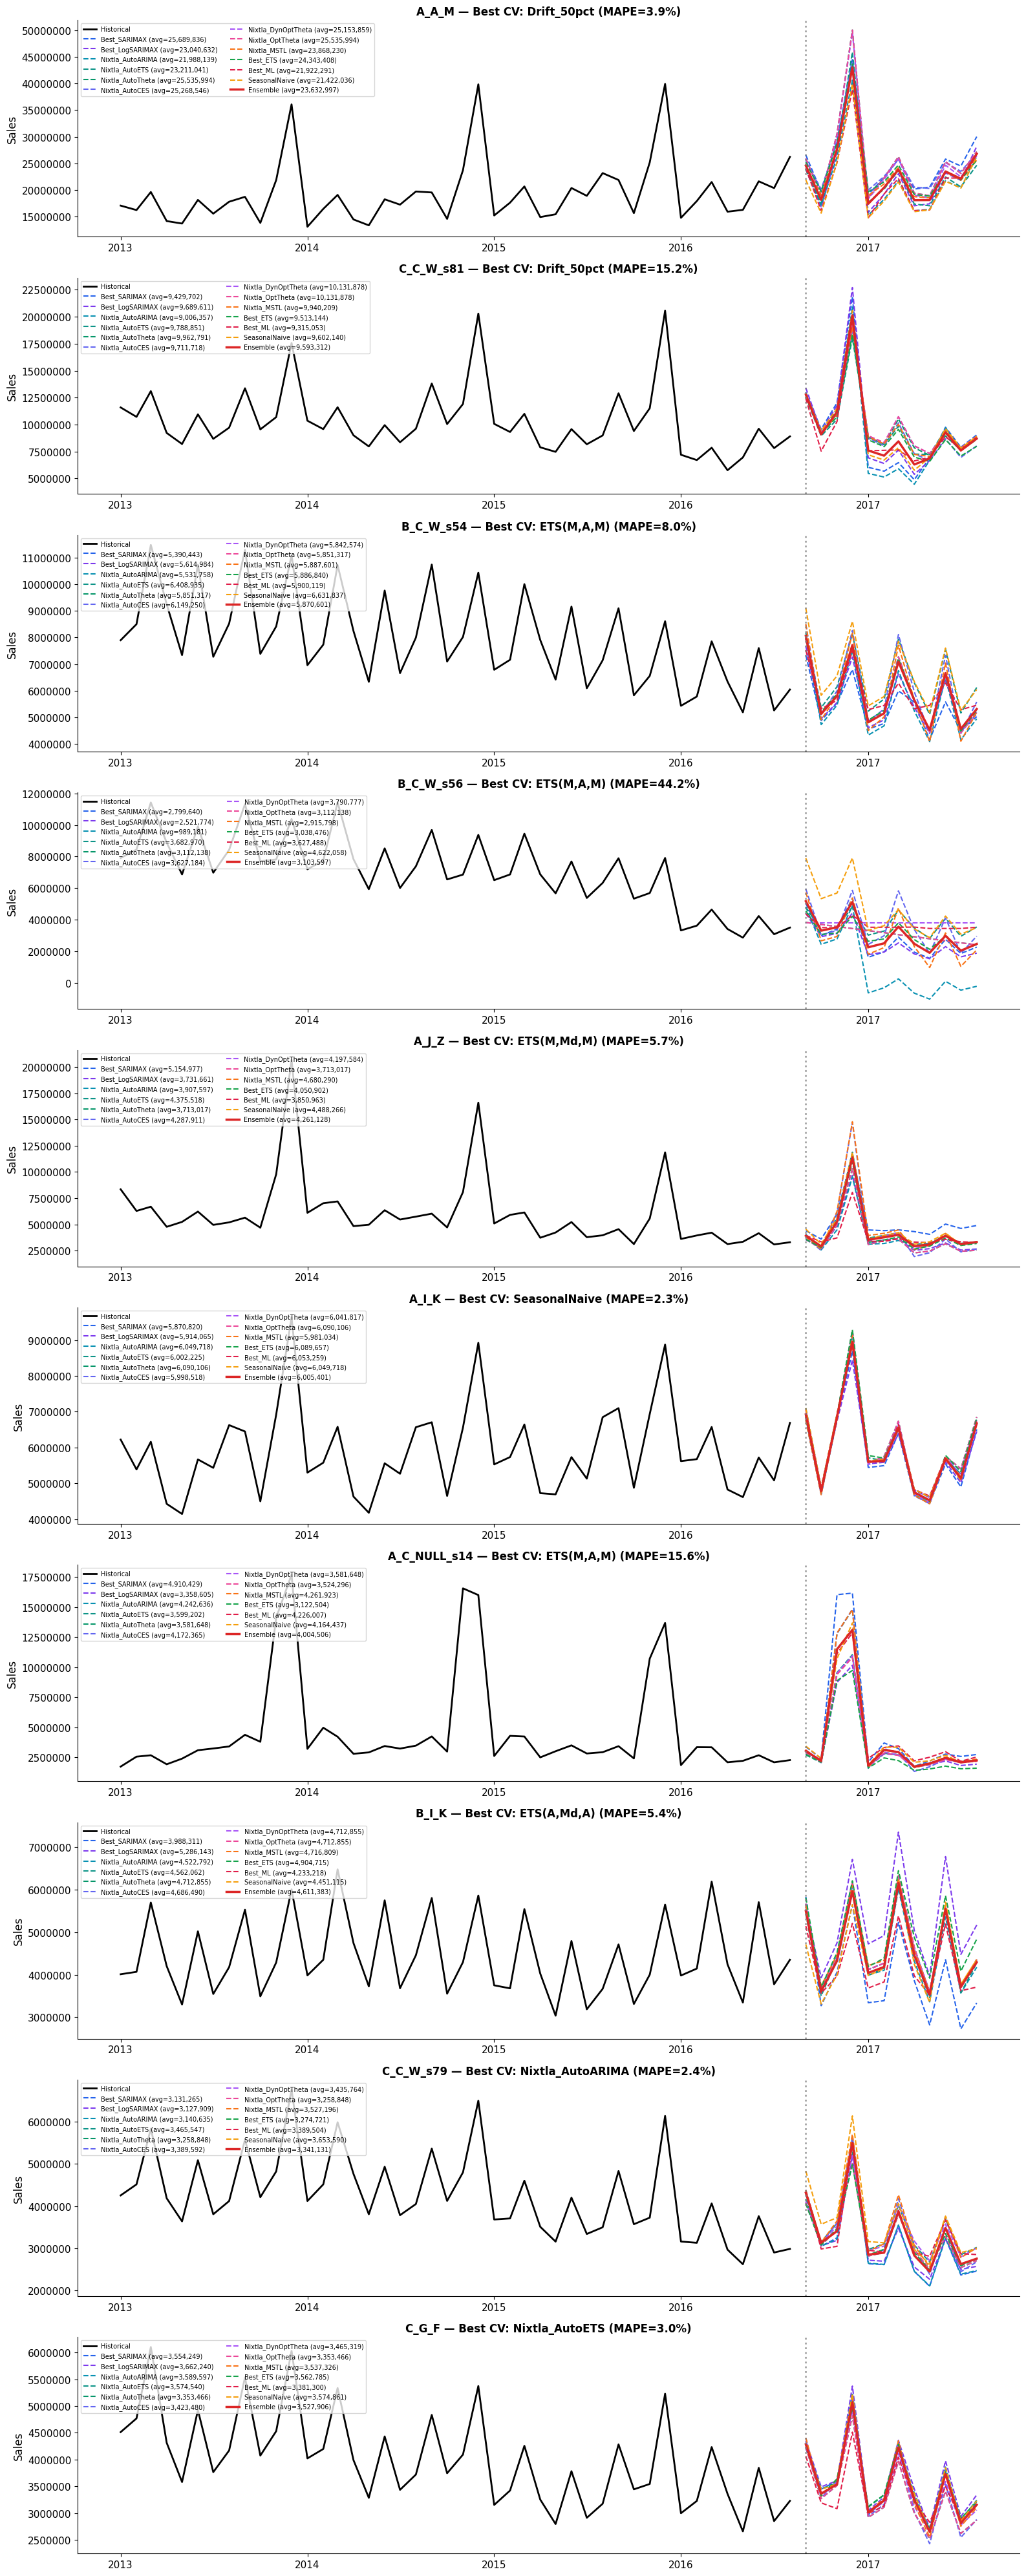

In [ ]:
# Plot forecasts for top 10 series (to keep readable)
plot_series = forecast_series[:10]
n_plots = len(plot_series)
fig, axes = plt.subplots(n_plots, 1, figsize=(16, 4*n_plots))
if n_plots == 1:
    axes = [axes]

forecast_start = df_final['date'].max() + pd.DateOffset(months=1)
forecast_dates = pd.date_range(forecast_start, periods=12, freq='MS')

model_colors = {
    'Best_SARIMAX': '#2563eb', 'Best_LogSARIMAX': '#7c3aed',
    'Best_ETS': '#16a34a', 'Best_ML': '#e11d48',
    'Nixtla_AutoARIMA': '#0891b2', 'Nixtla_AutoETS': '#0d9488', 'Nixtla_AutoTheta': '#059669',
    'Nixtla_AutoCES': '#6366f1', 'Nixtla_DynOptTheta': '#a855f7', 'Nixtla_OptTheta': '#ec4899',
    'Nixtla_MSTL': '#f97316',
    'SeasonalNaive': '#f59e0b', 'Ensemble': '#dc2626',
}

for i, sl in enumerate(plot_series):
    ax = axes[i]

    s = df_final[df_final['series_label']==sl].sort_values('date')
    ax.plot(s['date'], s['sales'], color='black', linewidth=2, label='Historical')

    for model_name, fc in all_forecasts[sl].items():
        color = model_colors.get(model_name, '#6b7280')
        lw = 2.5 if model_name == 'Ensemble' else 1.5
        ls = '-' if model_name == 'Ensemble' else '--'
        ax.plot(forecast_dates, fc, color=color, linewidth=lw, linestyle=ls,
                label=f'{model_name} (avg={np.mean(fc):,.0f})')

    ax.axvline(forecast_start, color='gray', linestyle=':', alpha=0.7)
    bm = all_best_models[sl]
    ax.set_title(f'{sl} — Best CV: {bm["best_cv_model"]} (MAPE={bm["cv_mape"]:.1f}%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Sales')
    ax.legend(fontsize=7, loc='upper left', ncol=2)
    ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## 4.5 Export Forecast Data

In [ ]:
# Export BEST MODEL forecast per series
best_forecast_output = []

for sl in forecast_series:
    bm = all_best_models[sl]
    best_name = bm['best_cv_model']
    fc_dict = all_forecasts[sl]

    # Map CV model name to forecast key
    if best_name.startswith('ETS('):
        fc_key = 'Best_ETS'
    elif best_name in ('GradientBoosting', 'RandomForest'):
        fc_key = 'Best_ML'
    elif best_name.startswith('Nixtla_'):
        fc_key = best_name
    elif best_name.startswith('Drift'):
        fc_key = 'SeasonalNaive'
    else:
        fc_key = best_name

    # Pick forecast with fallback: best -> ensemble -> seasonal naive
    if fc_key in fc_dict and np.all(np.isfinite(fc_dict[fc_key])):
        chosen_fc = fc_dict[fc_key]
        chosen_model = best_name
    elif 'Ensemble' in fc_dict:
        chosen_fc = fc_dict['Ensemble']
        chosen_model = 'Ensemble (fallback)'
    else:
        chosen_fc = fc_dict['SeasonalNaive']
        chosen_model = 'SeasonalNaive (fallback)'

    cat_key = summary_df[summary_df['series_label']==sl]['cat_key'].iloc[0]
    for j, (date, value) in enumerate(zip(forecast_dates, chosen_fc)):
        best_forecast_output.append({
            'Series': sl,
            'Category_Key': cat_key,
            'Best_Model': chosen_model,
            'CV_RMSE': round(bm['cv_rmse'], 2),
            'CV_MAPE': round(bm['cv_mape'], 2),
            'Date': date.strftime('%Y-%m'),
            'Forecast': round(value, 2)
        })

best_df = pd.DataFrame(best_forecast_output)
best_df.to_csv('forecast_best_model.csv', index=False)
files.download('forecast_best_model.csv')

print(f'Shape: {best_df.shape[0]} rows ({best_df["Series"].nunique()} series × 12 months)')
print(f'\nModel distribution:')
for m, cnt in best_df.groupby('Series')['Best_Model'].first().value_counts().items():
    print(f'  {m}: {cnt} series')
print(f'\nSample:')
best_df.head(15)

Shape: 1044 rows (87 series × 12 months)

Model distribution:
  ETS(M,A,M): 8 series
  Nixtla_AutoETS: 8 series
  Nixtla_AutoARIMA: 8 series
  SeasonalNaive: 7 series
  ETS(M,M,M): 7 series
  Nixtla_OptTheta: 5 series
  ETS(A,Md,A): 5 series
  ETS(M,Md,M): 5 series
  ETS(M,N,M): 4 series
  Nixtla_MSTL: 3 series
  Drift_75pct: 3 series
  GradientBoosting: 3 series
  Drift_25pct: 3 series
  Nixtla_DynOptTheta: 3 series
  Nixtla_AutoCES: 3 series
  Drift_50pct: 3 series
  ETS(A,M,A): 2 series
  RandomForest: 2 series
  ETS(A,Ad,A): 2 series
  ETS(M,Ad,M): 1 series
  ETS(A,A,A): 1 series
  ETS(A,N,A): 1 series

Sample:


,Series,Category_Key,Best_Model,CV_RMSE,CV_MAPE,Date,Forecast
0,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2016-09,"21,865,338"
1,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2016-10,"15,627,750"
2,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2016-11,"25,178,979"
3,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2016-12,"39,937,550"
4,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2017-01,"14,745,802"
5,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2017-02,"17,904,538"
6,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2017-03,"21,483,559"
7,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2017-04,"15,900,085"
8,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2017-05,"16,247,858"
9,A_A_M,A_A_M,Drift_50pct,"1,040,258",4,2017-06,"21,614,813"


In [ ]:
# Final summary: Best model + ensemble forecast for each series
print('='*90)
print('FORECAST SUMMARY — ALL SERIES (Ensemble 12-month average)')
print('='*90)

for sl in forecast_series:
    bm = all_best_models[sl]
    ensemble = all_forecasts[sl].get('Ensemble', all_forecasts[sl].get('SeasonalNaive', np.zeros(12)))
    ensemble_mean = np.mean(ensemble)
    hist_mean = df_final[df_final['series_label']==sl]['sales'].mean()

    print(f'{sl:<30} | Best: {bm["best_cv_model"]:<18} | MAPE: {bm["cv_mape"]:5.1f}% | '
          f'Hist avg: {hist_mean:>12,.0f} | Forecast avg: {ensemble_mean:>12,.0f}')

FORECAST SUMMARY — ALL SERIES (Ensemble 12-month average)
A_A_M                          | Best: Drift_50pct        | MAPE:   3.9% | Hist avg:   19,428,236 | Forecast avg:   23,632,997
C_C_W_s81                      | Best: Drift_50pct        | MAPE:  15.2% | Hist avg:   10,309,516 | Forecast avg:    9,593,312
B_C_W_s54                      | Best: ETS(M,A,M)         | MAPE:   8.0% | Hist avg:    7,956,510 | Forecast avg:    5,870,601
B_C_W_s56                      | Best: ETS(M,A,M)         | MAPE:  44.2% | Hist avg:    7,064,435 | Forecast avg:    3,103,597
A_J_Z                          | Best: ETS(M,Md,M)        | MAPE:   5.7% | Hist avg:    5,987,733 | Forecast avg:    4,261,128
A_I_K                          | Best: SeasonalNaive      | MAPE:   2.3% | Hist avg:    5,902,492 | Forecast avg:    6,005,401
A_C_NULL_s14                   | Best: ETS(M,A,M)         | MAPE:  15.6% | Hist avg:    4,649,127 | Forecast avg:    4,004,506
B_I_K                          | Best: ETS(A,Md,A)   

MAPE BY PRODUCT GROUP (Category2)
      mean_mape  median_mape  n_series  mean_sales
Cat2                                              
J            24           22        13     965,394
C           120           15        11   3,589,609
F            10           11         7     757,933
B             9            6         9     618,754
A            10            6        20   1,261,662
E             8            6         3   1,407,425
I             6            5        10   1,810,435
G             6            5        12   1,262,208
H             4            4         1     566,234
D             3            3         1   2,829,039

MAPE BY SUB-CATEGORY (Category3)
      mean_mape  median_mape  n_series  mean_sales
Cat3                                              
O            59           43         3      47,296
X            20           20         1       7,801
NULL        104           16        13   1,102,248
V            28           15         3      49,870
Z            1

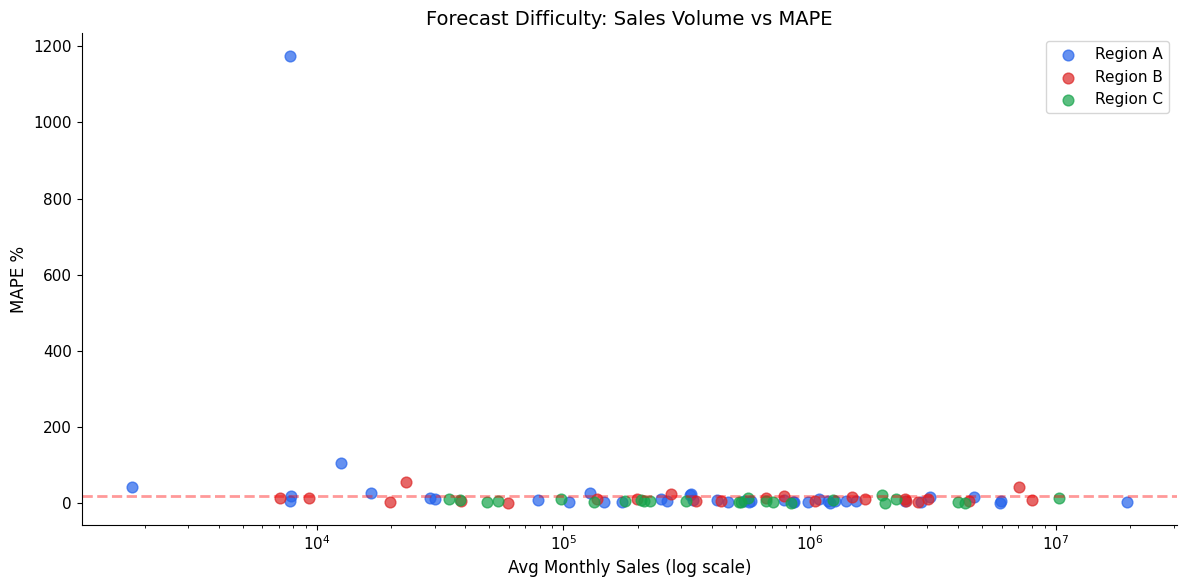

In [ ]:
# Analyze MAPE patterns by category
mape_analysis = []
for sl in forecast_series:
    bm = all_best_models[sl]
    row = summary_df[summary_df['series_label']==sl].iloc[0]
    mape_analysis.append({
        'series': sl,
        'Cat1': row['Category1'],
        'Cat2': row['Category2'],
        'Cat3': row['Category3'],
        'avg_sales': row['avg_monthly_sales'],
        'mape': bm['cv_mape'],
        'best_model': bm['best_cv_model'],
    })

mape_df = pd.DataFrame(mape_analysis)

# MAPE by Category2 (product group)
print('='*60)
print('MAPE BY PRODUCT GROUP (Category2)')
print('='*60)
cat2_mape = mape_df.groupby('Cat2').agg(
    mean_mape=('mape', 'mean'),
    median_mape=('mape', 'median'),
    n_series=('mape', 'count'),
    mean_sales=('avg_sales', 'mean')
).sort_values('median_mape', ascending=False)
print(cat2_mape.round(1).to_string())

# MAPE by Category3
print(f'\n{"="*60}')
print('MAPE BY SUB-CATEGORY (Category3)')
print(f'{"="*60}')
cat3_mape = mape_df.groupby('Cat3').agg(
    mean_mape=('mape', 'mean'),
    median_mape=('mape', 'median'),
    n_series=('mape', 'count'),
    mean_sales=('avg_sales', 'mean')
).sort_values('median_mape', ascending=False)
print(cat3_mape.round(1).to_string())

# Scatter: sales magnitude vs MAPE
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'A': '#2563eb', 'B': '#dc2626', 'C': '#16a34a'}
for cat1 in sorted(mape_df['Cat1'].unique()):
    sub = mape_df[mape_df['Cat1']==cat1]
    ax.scatter(sub['avg_sales'], sub['mape'], c=colors.get(cat1, 'gray'),
               label=f'Region {cat1}', s=60, alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Avg Monthly Sales (log scale)')
ax.set_ylabel('MAPE %')
ax.set_title('Forecast Difficulty: Sales Volume vs MAPE')
ax.legend()
ax.axhline(20, color='red', linestyle='--', alpha=0.4, label='20% threshold')
plt.tight_layout()
plt.show()

FORECAST QUALITY TIERS
                     n_series  median_mape  mean_sales  pct_series
tier                                                              
Good (<10%)                54            5   1,594,021          62
Acceptable (10-20%)        22           13   1,489,986          25
Poor (20-50%)               8           26   1,263,967           9
Unreliable (>50%)           3          107      14,394           3

PROBLEMATIC SERIES (MAPE > 20%)
      series Cat2 Cat3  avg_sales  mape         best_model
A_C_NULL_s16    C NULL      7,798 1,175       RandomForest
   A_J_O_s34    J    O     12,475   107 Nixtla_DynOptTheta
       B_A_V    A    V     22,907    58     Nixtla_AutoETS
   B_C_W_s56    C    W  7,064,435    44         ETS(M,A,M)
   A_J_O_s31    J    O      1,766    43         ETS(M,N,M)
A_J_NULL_s40    J NULL     16,590    28         ETS(A,M,A)
   A_J_O_s32    J    O    127,647    27         ETS(M,M,M)
    B_J_NULL    J NULL    272,786    25        ETS(A,Md,A)
A_J_NULL_s3

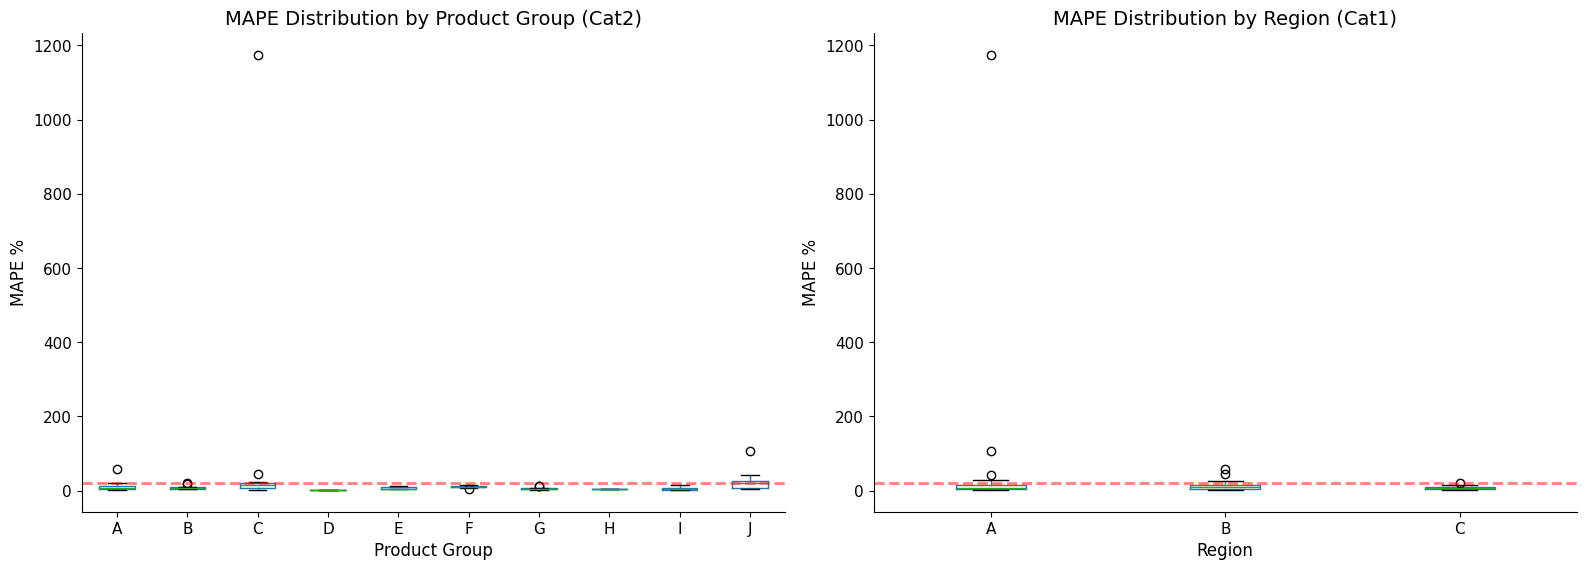

In [ ]:
# Flag series by MAPE quality tier
mape_df['tier'] = pd.cut(mape_df['mape'],
                          bins=[0, 10, 20, 50, float('inf')],
                          labels=['Good (<10%)', 'Acceptable (10-20%)', 'Poor (20-50%)', 'Unreliable (>50%)'])

# Summary by tier
print('='*60)
print('FORECAST QUALITY TIERS')
print('='*60)
tier_summary = mape_df.groupby('tier').agg(
    n_series=('mape', 'count'),
    median_mape=('mape', 'median'),
    mean_sales=('avg_sales', 'mean')
).round(1)
tier_summary['pct_series'] = (tier_summary['n_series'] / len(mape_df) * 100).round(1)
print(tier_summary.to_string())

# Show the problematic ones (MAPE > 20%)
print(f'\n{"="*60}')
print('PROBLEMATIC SERIES (MAPE > 20%)')
print(f'{"="*60}')
bad = mape_df[mape_df['mape'] > 20].sort_values('mape', ascending=False)
print(bad[['series','Cat2','Cat3','avg_sales','mape','best_model']].to_string(index=False))

# Box plot by Category2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mape_df.boxplot(column='mape', by='Cat2', ax=axes[0], grid=False)
axes[0].set_title('MAPE Distribution by Product Group (Cat2)')
axes[0].set_ylabel('MAPE %')
axes[0].set_xlabel('Product Group')
axes[0].axhline(20, color='red', linestyle='--', alpha=0.5)

mape_df.boxplot(column='mape', by='Cat1', ax=axes[1], grid=False)
axes[1].set_title('MAPE Distribution by Region (Cat1)')
axes[1].set_ylabel('MAPE %')
axes[1].set_xlabel('Region')
axes[1].axhline(20, color='red', linestyle='--', alpha=0.5)

plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
# Flag unreliable forecasts and document reasoning
mape_df['reliable'] = mape_df['mape'] <= 20

print('='*60)
print('FORECAST RELIABILITY SUMMARY')
print('='*60)
print(f'  Reliable (MAPE <= 20%):   {mape_df["reliable"].sum()}/{len(mape_df)} series '
      f'({mape_df["reliable"].mean()*100:.0f}%)')
print(f'  Unreliable (MAPE > 20%):  {(~mape_df["reliable"]).sum()}/{len(mape_df)} series')

print(f'\nUnreliable series share common traits:')
bad = mape_df[~mape_df['reliable']]
print(f'  - {(bad["Cat2"]=="J").sum()}/{len(bad)} are Product Group J (erratic/declining products)')
print(f'  - {(bad["Cat3"]=="NULL").sum()}/{len(bad)} have Category3=NULL (catch-all buckets)')
print(f'  - {(bad["avg_sales"]<100000).sum()}/{len(bad)} have avg sales < 100K (low volume = high noise)')
print(f'  - Median avg sales: {bad["avg_sales"].median():,.0f} vs '
      f'{mape_df[mape_df["reliable"]]["avg_sales"].median():,.0f} for reliable series')

print(f'\nRecommendation:')
print(f'  For the {len(bad)} unreliable series, statistical forecasts should be')
print(f'  supplemented with qualitative business judgment. These products are')
print(f'  either declining, low-volume, or miscategorized — patterns that no')
print(f'  time series model can reliably capture with 44 months of history.')

FORECAST RELIABILITY SUMMARY
  Reliable (MAPE <= 20%):   76/87 series (87%)
  Unreliable (MAPE > 20%):  11/87 series

Unreliable series share common traits:
  - 7/11 are Product Group J (erratic/declining products)
  - 5/11 have Category3=NULL (catch-all buckets)
  - 5/11 have avg sales < 100K (low volume = high noise)
  - Median avg sales: 127,647 vs 571,184 for reliable series

Recommendation:
  For the 11 unreliable series, statistical forecasts should be
  supplemented with qualitative business judgment. These products are
  either declining, low-volume, or miscategorized — patterns that no
  time series model can reliably capture with 44 months of history.


---
# Part 5: Critique & Next Steps

## Strengths of the Approach

| Strength | Detail |
|----------|--------|
| **Thorough data cleaning** | Systematically addressed all data quality issues (empty rows, zeros, negatives, discontinued products) with documented rationale for each decision |
| **Individual series treatment** | Kept each sub-product as its own series rather than aggregating "duplicates" — prevents signal contamination between products of vastly different magnitudes (e.g., 350M vs 632) |
| **14 model types** | SARIMAX, Log-SARIMAX, ETS (10 configs), 7 Nixtla models, Gradient Boosting, Random Forest, Seasonal Naive, Drift — covers statistical, automated, ML, and baseline families |
| **Nixtla StatsForecast (7 models)** | AutoARIMA, AutoETS, AutoTheta, AutoCES, DynOptTheta, OptTheta, MSTL — each captures different data dynamics (autocorrelation, exponential smoothing, cyclical, trend-adaptive, decomposition-based) |
| **Principled model selection** | AIC for SARIMAX (appropriate for short series and forecasting objectives vs BIC), expanding-window CV for ETS/ML/baselines, automatic selection for Nixtla |
| **ML with feature engineering** | 12 lag features, rolling statistics, sin/cos calendar encoding, recursive multi-step forecasting |
| **Robust evaluation** | 2-fold expanding window CV with both RMSE (within-series optimization) and MAPE (cross-series comparison) |
| **Ensemble method** | Averages best models from each family (statistical, Nixtla, ML, baseline) — diversity reduces variance and protects against individual model failures |
| **Full coverage** | Forecasted all 87+ viable product series, not just the top few |

## Limitations

| Limitation | Impact | Potential Mitigation |
|------------|--------|---------------------|
| **No exogenous variables** | Promotions, economic indicators, and marketing spend are not captured | SARIMAX supports exogenous regressors if data becomes available |
| **Short history (44 months)** | Limits complexity of seasonal models and ML training set size | Collect more data; use Bayesian priors to regularize |
| **No hierarchical reconciliation** | Sub-product forecasts don't sum to region/group totals | Apply MinT optimal or bottom-up reconciliation |
| **AIC only (no BIC comparison)** | AIC may occasionally select slightly overfit models | Could run both and compare, but AIC is preferred for forecasting per Hyndman & Athanasopoulos |
| **Limited ML training data** | ~20 usable rows after feature engineering — ML models may underfit | Global ML models across all series could share patterns |
| **No prediction intervals** | Point forecasts only; no confidence bands | Add via bootstrapping, conformal prediction, or Nixtla's built-in intervals |